In [2]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re # For regular expression matching
from pathlib import Path
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
import os
import seaborn as sns
from scipy.stats import mannwhitneyu


In [ ]:
adata_raw_filter = sc.read("../Data/figure6/Raw_filter_5_9_10_11.h5ad")
adata_norm_filter = sc.read("../Data/figure6/Normalized_filter_5_9_10_11.h5ad")

In [ ]:
# plot the umap and save it to the folder kai_figure
folder = "../figure"
Path(folder).mkdir(parents=True, exist_ok=True)
sc.settings.figdir = folder
# sc.settings.set_figure_params(dpi=200, facecolor='white')



In [4]:
def plot_marker_gene_summary(
    adata,
    marker_genes,
    groupby_col,
    output_dir,
    n_top_genes_heatmap=50
):
    """
    Generates a heatmap and a dot plot for a given list of marker genes.

    Args:
        adata (sc.AnnData): The annotated AnnData object.
        marker_genes (list): A list of gene names to plot.
        groupby_col (str): The column name in adata.obs to group cells by.
        output_dir (str): Path to the directory where plots will be saved.
        n_top_genes_heatmap (int): Number of top variable genes from the list to show in the heatmap for clarity.
    """
    print(f"\nGenerating summary plots for marker genes, grouping by '{groupby_col}'...")
    Path(output_dir).mkdir(parents=True, exist_ok=True)

    # Filter marker genes to only those present in the data
    genes_in_data = [gene for gene in marker_genes if gene in adata.var_names]
    if not genes_in_data:
        print("Warning: None of the provided marker genes were found in the AnnData object. Skipping summary plots.")
        return

    # --- 1. Dot Plot (can handle many genes) ---
    print("Generating dot plot...")
    sc.pl.dotplot(adata, genes_in_data, groupby=groupby_col, standard_scale="var",dendrogram=True, show=False)
    plt.title("Marker Gene Expression Across Clusters")
    plt.tight_layout()
    filename_dotplot = f"{output_dir}/marker_gene_dotplot.pdf"
    plt.savefig(filename_dotplot, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Dot plot saved to {filename_dotplot}")

    # --- 2. Heatmap (better with fewer genes for readability) ---
    print("Generating heatmap...")
    # For heatmaps, it's often better to show the most variable genes from the list
    adata_markers = adata[:, genes_in_data].copy()
    # Find the most variable genes within our provided list
    sc.pp.highly_variable_genes(adata_markers, n_top_genes=min(n_top_genes_heatmap, len(genes_in_data)))
    variable_marker_genes = adata_markers.var[adata_markers.var.highly_variable].index.tolist()

    if not variable_marker_genes:
         print("Warning: Could not identify variable marker genes for heatmap. Using the full list (may be slow/unreadable).")
         variable_marker_genes = genes_in_data

    sc.pl.heatmap(adata, variable_marker_genes, groupby=groupby_col, show=False, cmap='viridis', dendrogram=True)
    filename_heatmap = f"{output_dir}/marker_gene_heatmap.pdf"
    plt.savefig(filename_heatmap, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Heatmap saved to {filename_heatmap}")


In [ ]:

MARKER_GENES = [
        'RORC', 'RORC202', 'RORA', 'BCL6', 'IL7R', 'CXCR3', 'CXCR4', 'IL17F', 'CCL20', 'TNF',
        'IL26', 'IL22', 'IFNG', 'CSF1', 'TNFRSF9', 'IL23R', 'IL1R1', 'TBX21', 'ID2', 'IRF4',
        'BATF', 'PRDM1', 'IL22', 'CD70', 'KLF2', 'ITGB1', 'S1PR4', 'SELL', 'SAMHD1', 'ITGB7',
        'S1PR1', 'CD28', 'SLAMF6', 'CD96', 'SOS1', 'JAK3', 'SLC1A4', 'CCR5', 'CXCR6', 'BHLHE40',
        'CD69', 'STAT1', 'RUNX1', 'CCL5', 'TCF7L', 'CCR7', 'MAL', 'IL6ST', 'NELL2', 'FOXO1',
        'CXCR5', 'RRM2', 'MKI67', 'PKMYT1', 'CCNB1', 'CDKN2C', 'CCNA2', 'CCNB2', 'E2F1', 'EPAS1',
        'TNFRSF8', 'CTLA4', 'TNFRSF11A', 'MAF', 'IKZF3', 'IL2RB', 'CCR6', 'CCR4', 'CCL3', 'CCL4',
        'CCL4L2', 'GZMB', 'GZMH', 'CCL8', 'FASLG', 'HAVCR2', 'SLAMF1', 'TNFSF9', 'STAT4', 'TNFSF8',
        'TIGIT', 'BACH2', 'VSIR', 'IRF8', 'IL4R', 'IFNGR2', 'IL21R', 'IRF1', 'PSAT1', 'XBP1',
        'GPX4', 'SQSTM1', 'SLC7A11', 'MYB', 'IL2', 'STAT5A', 'TNFSF14', 'REL', 'LIF', 'SLAMF7',
        'FOXP1', 'DDIT3', 'NBR1', 'STAT2'
    ]

NEW_MARKER_GENES = [
    'RORC', 'RORC202', 'RORA', 'IL7R', 'CXCR3', 'CXCR4', 'IL17F', 'IL17A', 
    'CCL20', 'TNF', 'IL26', 'IL22', 'IRF4', 'KLF2', 'S1PR1', 'S1PR4', 
    'ITGB1', 'ITGB7', 'CD96', 'BHLHE40', 'CD69', 'CCR5', 'CXCR6', 'TCF7L', 
    'CCR7', 'MAL', 'IL6ST', 'NELL2', 'RRM2', 'MKI67', 'CCNB1', 'CCNA2', 
    'CCNB2', 'CCR6', 'EPAS1', 'TNFRSF8', 'IKZF3', 'MAF', 'IFNG', 'CCL3', 
    'CCL4', 'GZMB', 'GZMH', 'STAT4', 'FOXO1', 'CXCR5', 'TNFSF8', 'IL21R', 
    'MYB', 'IRF1', 'XBP1', 'GPX4', 'SQSTM1'
]
gene_list = [
    "RORC", "RORC202", "RORA", "IL32", "CCR4", "TNF", "IL17F", "CCL3", "CCL20",
    "KLF2", "S1PR1", "S1PR4", "ITGB1", "ITGA6", "CCR5", "CXCR6", "STAT1",
    "BHLHE40", "CD69", "ANXA1", "IL6ST", "TCF7L", "TIGIT", "CXCR5", "RRM2",
    "MKI67", "CCNB1", "CCNA2", "CCNB2", "IL17A", "IL26", "IL22", "IL23R",
    "PDIA4", "YBX3", "STING1", "CD28", "IKZF3", "CD70", "MYC", "CASP3", "IFNG",
    "CCL4", "GZMB", "GZMH", "CCL5", "FASLG", "BACH2", "STAT4", "IL2", "TNFSF8",
    "LIF", "IL21R", "SLC7A11", "XBP1", "GPX4", "DDIT3", "SQSTM1"
]

CONDITION_COLUMN = 'condition' # Replace with the actual column name in your adata.obs
GENOTYPE_COLUMN = 'genotype_annotation' # The column with your detailed annotations
OUTPUT_FOLDER = '../figures/new_cluster_map'
os.makedirs(OUTPUT_FOLDER, exist_ok=True)
plot_marker_gene_summary(
    adata=adata_norm_filter,
    marker_genes=gene_list,
    groupby_col="leiden_clusters",
    output_dir=OUTPUT_FOLDER
)


Generating summary plots for marker genes, grouping by 'leiden_clusters'...
Generating dot plot...


/tmp/ipykernel_9985/3406946193.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Dot plot saved to ../10_27_kai_figure/new_cluster_map/marker_gene_dotplot.pdf
Generating heatmap...
Heatmap saved to ../10_27_kai_figure/new_cluster_map/marker_gene_heatmap.pdf


# STEP 5

In [5]:
all_genotypes = adata_norm_filter.obs["genotype_annotation"].unique().tolist()
print("Available genotypes in the dataset:", all_genotypes)



Available genotypes in the dataset: ['unedited', 'RORC-rs949969_hom_bystander', 'RORC-rs949969_hom_pure', 'RORC-rs55895543_hom_bystander', 'RORC-rs11578418_hom_pure', 'RORC-RORCT-SPA4_het_bystander', 'RORC-rs7523001_hom_bystander', 'RORC-rs10888436_hom_pure', 'RORC-RORCT-SPA4_hom_bystander', 'RORC-rs11586691_hom_bystander', 'AAVS_ACBE3', 'AAVS4_Any_Pure', 'RORC-rs7523001_wt_pure', 'RORC-rs7523001_hom_pure', 'RORC-rs949969_het_bystander', 'RORC-rs4845556_hom_pure', 'mixed', 'RORC-rs80223568_hom_pure', 'RORC-rs11801866_het_pure', 'RORC-rs12030974_hom_bystander', 'RORC-rs79051659_hom_pure', 'RORC-rs4845556_wt_pure', 'RORC-RORCT-ST_het_pure', 'RORC-rs79051659_het_bystander', 'RORC-rs11578418_het_pure', 'RORC-rs10888436_hom_bystander', 'RORC-rs79051659_het_pure', 'RORC-rs11204894_het_bystander', 'RORC-rs55895543_hom_pure', 'RORC-RORCT-SPA4_het_pure', 'RORC-RORCT-ST_hom_bystander', 'RORC-rs4845604_het_bystander', 'RORC-rs7523001_wt_bystander', 'TNRC18-rs748670681_hom_bystander', 'RORC-rs5589

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import configparser
import scanpy as sc # Assuming usage with AnnData
from scipy.stats import mannwhitneyu

def add_stat_annotation(ax, df, control_name, order):
    """Adds p-value annotations to the plot."""
    y_max = df['Expression'].max()
    y_step = y_max * 0.08  # Step size for annotation lines

    pairs = [(control_name, 'Het'), (control_name, 'Hom')]
    
    # Map simplified names back to original names for indexing if needed
    name_map = {'Het': order[1], 'Hom': order[2]}

    for i, (g1_simple, g2_simple) in enumerate(pairs):
        y_level = y_max + (i + 1) * y_step
        
        g1_data = df[df['Genotype'] == g1_simple]['Expression']
        
        # Determine the full name for g2 for data retrieval
        g2_full = name_map.get(g2_simple, g2_simple) 
        g2_data = df[df['Genotype'] == g2_full]['Expression']

        if len(g1_data) < 2 or len(g2_data) < 2:
            continue

        _, p_val = mannwhitneyu(g1_data, g2_data, alternative='two-sided')

        p_text = f"p={p_val:.1e}" if p_val < 0.05 else "p>0.05"
        
        x1 = order.index(g1_simple)
        x2 = order.index(g2_full)

        ax.plot([x1, x1, x2, x2], [y_level, y_level + y_step*0.2, y_level + y_step*0.2, y_level], lw=1.5, c='k')
        ax.text((x1 + x2) * 0.5, y_level + y_step*0.2, p_text, ha='center', va='bottom', color='k')


def _generate_single_plot(df, order, title, filename, control_name):
    """Helper function to generate a single boxplot with a stripplot and annotations."""
    if df.empty:
        return

    fig, ax = plt.subplots(figsize=(4, 10))
    
    # Boxplot without outliers
    sns.boxplot(
        data=df, x='Genotype', y='Expression', order=order, ax=ax,
        showfliers=False, palette="Set2"
    )
    
    # Stripplot to show individual points
    sns.stripplot(
        data=df, x='Genotype', y='Expression', order=order, ax=ax,
        jitter=0.2,  # Increase the jitter width
        alpha=0.6,
        size=4,      # Slightly increased point size
        palette="Set2"
    )
    
    # Add p-value annotations
    add_stat_annotation(ax, df, control_name, order)

    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Genotype", fontsize=12)
    ax.set_ylabel("Normalized Expression", fontsize=12)
    
    # Adjust y-limit to make space for annotations
    ax.set_ylim(top=ax.get_ylim()[1] * 1.2)
    
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.close()


def plot_genotype_boxplots(
    adata, config_path, genes_to_plot, condition_col, genotype_col, output_dir
):
    """
    Generates box plots of gene expression with stripplots and p-value annotations.
    """
    # --- 1. Setup and Config Parsing ---
    Path(output_dir).mkdir(parents=True, exist_ok=True)
    config = configparser.ConfigParser()
    config.read(config_path)
    
    variant_to_group = {s: config.get(s, 'group') for s in config.sections()}
    controls = {'Base Editing': 'AAVS_ACBE3', 'HDR': 'AAVS4_Any_Pure'}
    
    # --- 2. Main Plotting Loop ---
    variants = [v for v in variant_to_group if v not in ["AAVS-ACBE3", "AAVS4"]]
    conditions = adata.obs[condition_col].unique()

    print(f"Starting plot generation for {len(conditions)} conditions, {len(genes_to_plot)} genes, and {len(variants)} variants.")

    for condition in conditions:
        adata_cond = adata[adata.obs[condition_col] == condition].copy()
        for gene in genes_to_plot:
            if gene not in adata.var_names:
                print(f"Warning: Gene '{gene}' not found. Skipping.")
                continue

            for variant in variants:
                group = variant_to_group.get(variant)
                if not group or group not in controls:
                    continue
                control_name = controls[group]

                # --- Plot for 'pure' genotypes ---
                genotypes_pure = [control_name, f"{variant}_het_pure", f"{variant}_hom_pure"]
                adata_subset = adata_cond[adata_cond.obs[genotype_col].isin(genotypes_pure)].copy()
                
                if adata_subset.X.shape[0] > 0:
                    df_plot = pd.DataFrame({
                        'Expression': adata_subset[:, gene].X.toarray().flatten(),
                        'Genotype': adata_subset.obs[genotype_col]
                    })
                    rename_map = {f"{variant}_het_pure": "Het Pure", f"{variant}_hom_pure": "Hom Pure"}
                    df_plot['Genotype'].replace(rename_map, inplace=True)
                    order = [control_name, "Het Pure", "Hom Pure"]
                    
                    safe_name = variant.replace('-', '_').replace('.', '_')
                    filename = f"{output_dir}/{condition}_{gene}_{safe_name}_comparison.pdf"
                    title = f"{gene} Expression in {condition}\n({variant})"
                    
                    _generate_single_plot(df_plot, order, title, filename, control_name)

                # --- Plot for 'bystander' genotypes ---
                genotypes_bystander = [control_name, f"{variant}_het_bystander", f"{variant}_hom_bystander"]
                adata_subset_bystander = adata_cond[adata_cond.obs[genotype_col].isin(genotypes_bystander)].copy()

                if adata_subset_bystander.X.shape[0] > 0:
                    df_bystander = pd.DataFrame({
                        'Expression': adata_subset_bystander[:, gene].X.toarray().flatten(),
                        'Genotype': adata_subset_bystander.obs[genotype_col]
                    })
                    rename_map = {f"{variant}_het_bystander": "Het Bystander", f"{variant}_hom_bystander": "Hom Bystander"}
                    df_bystander['Genotype'].replace(rename_map, inplace=True)
                    order = [control_name, "Het Bystander", "Hom Bystander"]

                    safe_name = variant.replace('-', '_').replace('.', '_')
                    filename = f"{output_dir}/{condition}_{gene}_{safe_name}_bystander_comparison.pdf"
                    title = f"{gene} Expression in {condition}\n({variant} Bystander)"

                    _generate_single_plot(df_bystander, order, title, filename, control_name)

    print("Plotting complete.")

In [9]:
[i for i in adata_norm_filter.var_names if "RORC" in i]

['RORC', 'RORC201', 'RORC202']

In [ ]:

# 1. Load your data
# adata = sc.read_h5ad("path/to/your/annotated_adata.h5ad")
# adata.obs['condition'] = [...] # Make sure you have a condition column
import os
# 2. Define your parameters
CONFIG_FILE = 'rorc.ini' # Make sure this file is in the same directory
GENES = [
    'RORC', 'RORC201', 'RORC202', 'IL17A', 'IL17F', 'TNF', 
    'IL26', 'IL22', 'CCL20', 'ENSG00000234614'
]
# GENES = ['RORC']
CONDITION_COLUMN = 'condition' # Replace with the actual column name in your adata.obs
GENOTYPE_COLUMN = 'genotype_annotation' # The column with your detailed annotations
OUTPUT_FOLDER = f'../figures/{CONDITION_COLUMN}_normal_genotype_boxplots'
os.makedirs(OUTPUT_FOLDER, exist_ok=True)
# 3. Create a mock AnnData object for demonstration purposes
# In your real use case, you would skip this part and use your actual data.
adata_boxplot = adata_norm_filter.copy()  # Use your actual AnnData object here
# 4. Run the plotting function
plot_genotype_boxplots(
    adata=adata_boxplot,
    config_path=CONFIG_FILE,
    genes_to_plot=GENES,
    condition_col=CONDITION_COLUMN,
    genotype_col=GENOTYPE_COLUMN,
    output_dir=OUTPUT_FOLDER
)


Starting plot generation for 2 conditions, 10 genes, and 21 variants.


/tmp/ipykernel_5475/1908908785.py:122: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_plot['Genotype'].replace(rename_map, inplace=True)
/tmp/ipykernel_5475/1908908785.py:122: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df_plot['Genotype'].replace(rename_map, inplace=True)
/tmp/ipykernel_5475/1908908785.py:50: F

Plotting complete.


In [ ]:

# 1. Load your data
# adata = sc.read_h5ad("path/to/your/annotated_adata.h5ad")
# adata.obs['condition'] = [...] # Make sure you have a condition column
import os
# 2. Define your parameters
CONFIG_FILE = 'rorc.ini' # Make sure this file is in the same directory
GENES = [
    'RORC', 'RORC201', 'RORC202', 'IL17A', 'IL17F', 'TNF', 
    'IL26', 'IL22', 'CCL20', 'ENSG00000234614'
]
# GENES = ['RORC']
CONDITION_COLUMN = 'leiden_clusters' # Replace with the actual column name in your adata.obs
GENOTYPE_COLUMN = 'genotype_annotation' # The column with your detailed annotations
OUTPUT_FOLDER = f'../figures/{CONDITION_COLUMN}_normal_genotype_boxplots'
os.makedirs(OUTPUT_FOLDER, exist_ok=True)
# 3. Create a mock AnnData object for demonstration purposes
# In your real use case, you would skip this part and use your actual data.
adata_boxplot = adata_norm_filter.copy()  # Use your actual AnnData object here
# 4. Run the plotting function
plot_genotype_boxplots(
    adata=adata_boxplot,
    config_path=CONFIG_FILE,
    genes_to_plot=GENES,
    condition_col=CONDITION_COLUMN,
    genotype_col=GENOTYPE_COLUMN,
    output_dir=OUTPUT_FOLDER
)


Starting plot generation for 9 conditions, 10 genes, and 21 variants.


/tmp/ipykernel_5475/1908908785.py:122: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_plot['Genotype'].replace(rename_map, inplace=True)
/tmp/ipykernel_5475/1908908785.py:122: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df_plot['Genotype'].replace(rename_map, inplace=True)
/tmp/ipykernel_5475/1908908785.py:50: F

Plotting complete.


In [12]:
def plot_germline_boxplots(
    adata,
    config_path,
    genes_to_plot,
    condition_col,
    genotype_col,
    output_dir
):
    """
    Generates enhanced box plots (with stripplots and p-values) for germline variants.
    """
    # --- 1. Setup and Config Parsing ---
    Path(output_dir).mkdir(parents=True, exist_ok=True)
    config = configparser.ConfigParser()
    config.read(config_path)
    
    variant_to_group = {s: config.get(s, 'group') for s in config.sections()}
    controls = {'Base Editing': 'AAVS_ACBE3', 'HDR': 'AAVS4_Any_Pure'}
    
    germline_variants = ['RORC-rs4845556', 'RORC-rs11586691', 'RORC-rs7523001']
    
    # --- 2. Main Plotting Loop ---
    conditions = adata.obs[condition_col].unique()
    print(f"Starting plot generation for {len(conditions)} conditions, {len(genes_to_plot)} genes, and {len(germline_variants)} variants.")

    for condition in conditions:
        adata_cond = adata[adata.obs[condition_col] == condition].copy()
        for gene in genes_to_plot:
            if gene not in adata.var_names:
                print(f"Warning: Gene '{gene}' not found. Skipping.")
                continue

            for variant in germline_variants:
                group = variant_to_group.get(variant)
                if not group or group not in controls:
                    continue 

                control_name = controls[group]
                safe_variant_name = variant.replace('-', '_').replace('.', '_')
                
                # --- Plotting Set 1: Pure Comparison ---
                genotypes_pure = [control_name, f"{variant}_wt_pure", f"{variant}_hom_pure"]
                adata_plot_pure = adata_cond[adata_cond.obs[genotype_col].isin(genotypes_pure)].copy()
                
                if adata_plot_pure.X.shape[0] > 0:
                    df_plot_pure = pd.DataFrame({
                        'Expression': adata_plot_pure[:, gene].X.toarray().flatten(),
                        'Genotype': adata_plot_pure.obs[genotype_col]
                    }).replace({
                        f"{variant}_wt_pure": "WT Pure",
                        f"{variant}_hom_pure": "Hom Pure"
                    })
                    
                    order = [control_name, "WT Pure", "Hom Pure"]
                    title = f"{gene} Expression in {condition}\n({variant} - Pure)"
                    filename = f"{output_dir}/{condition}_{gene}_{safe_variant_name}_pure_comparison.pdf"
                    
                    _generate_single_plot(df_plot_pure, order, title, filename, control_name)

                # --- Plotting Set 2: Bystander Comparison ---
                genotypes_by = [control_name, f"{variant}_wt_bystander", f"{variant}_hom_bystander"]
                adata_plot_by = adata_cond[adata_cond.obs[genotype_col].isin(genotypes_by)].copy()

                if adata_plot_by.X.shape[0] > 0:
                    df_plot_by = pd.DataFrame({
                        'Expression': adata_plot_by[:, gene].X.toarray().flatten(),
                        'Genotype': adata_plot_by.obs[genotype_col]
                    }).replace({
                        f"{variant}_wt_bystander": "WT Bystander",
                        f"{variant}_hom_bystander": "Hom Bystander"
                    })

                    order = [control_name, "WT Bystander", "Hom Bystander"]
                    title = f"{gene} Expression in {condition}\n({variant} - Bystander)"
                    filename = f"{output_dir}/{condition}_{gene}_{safe_variant_name}_bystander_comparison.pdf"
                    
                    _generate_single_plot(df_plot_by, order, title, filename, control_name)

    print("Plotting complete.")

In [ ]:

# 2. Define your parameters
CONFIG_FILE = 'rorc.ini' # Make sure this file is in the same directory
GENES = [
    'RORC', 'RORC201', 'RORC202', 'IL17A', 'IL17F', 'TNF', 
    'IL26', 'IL22', 'CCL20', 'ENSG00000234614'
]
CONDITION_COLUMN = 'condition' # Replace with the actual column name in your adata.obs
GENOTYPE_COLUMN = 'genotype_annotation' # The column with your detailed annotations
OUTPUT_FOLDER = f'../figures/{CONDITION_COLUMN}_germline_genotype_boxplots'
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# 4. Run the plotting function
plot_germline_boxplots(
    adata=adata_boxplot,
    config_path=CONFIG_FILE,
    genes_to_plot=GENES,
    condition_col=CONDITION_COLUMN,
    genotype_col=GENOTYPE_COLUMN,
    output_dir=OUTPUT_FOLDER
)


Starting plot generation for 2 conditions, 10 genes, and 3 variants.


/tmp/ipykernel_5475/4103099702.py:46: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df_plot_pure = pd.DataFrame({
/tmp/ipykernel_5475/1908908785.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_5475/1908908785.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
/tmp/ipykernel_5475/4103099702.py:65: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for c

Plotting complete.


In [ ]:

# 2. Define your parameters
CONFIG_FILE = 'rorc.ini' # Make sure this file is in the same directory
GENES = [
    'RORC', 'RORC201', 'RORC202', 'IL17A', 'IL17F', 'TNF', 
    'IL26', 'IL22', 'CCL20', 'ENSG00000234614'
]
CONDITION_COLUMN = 'leiden_clusters' # Replace with the actual column name in your adata.obs
GENOTYPE_COLUMN = 'genotype_annotation' # The column with your detailed annotations
OUTPUT_FOLDER = f'../figures/{CONDITION_COLUMN}_germline_genotype_boxplots'
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# 4. Run the plotting function
plot_germline_boxplots(
    adata=adata_boxplot,
    config_path=CONFIG_FILE,
    genes_to_plot=GENES,
    condition_col=CONDITION_COLUMN,
    genotype_col=GENOTYPE_COLUMN,
    output_dir=OUTPUT_FOLDER
)



Starting plot generation for 9 conditions, 10 genes, and 3 variants.


/tmp/ipykernel_5475/4103099702.py:46: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df_plot_pure = pd.DataFrame({
/tmp/ipykernel_5475/1908908785.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_5475/1908908785.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
/tmp/ipykernel_5475/4103099702.py:65: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for c

Plotting complete.


In [15]:
# make boxplot for each variant for genes: RORC, RORC201,RORC202, IL17A, IL17F, TNF, IL26, IL22, CCL20, , ENSG00000234614

adata_norm_filter.obs["genotype_annotation"].value_counts().to_csv(f"{folder}/genotype_annotation_counts.csv")

# STEP 6

In [ ]:
# regenerate the DEG table for each variant 
import scanpy as sc
import pandas as pd
import numpy as np
from pathlib import Path
import re
import configparser # <-- ADDED: Import configparser


# --- Configuration ---
config_file_path = 'rorc.ini' # <-- ADDED: UPDATE THIS PATH

# geno = sc.read("/mnt/data/project/25_04_29_Figure3_reanalysis/data_anders/tapestri_adata.h5ad")
genotype_col = 'genotype_annotation'
condition_col = 'condition'
wt_genotype_label = 'AAVS_ACBE3' # Genotype to compare against

# DE Analysis Parameters
de_method = 'wilcoxon'
de_corr_method = 'benjamini-hochberg'
# No filtering thresholds needed here as we save all genes

# Output directory and file
output_dir = Path(f'../Data/figure6/figures/AAV4_hom_pure_Remove_GEM_AMP_0_deg_vs_{wt_genotype_label}_wide_table') # Updated output dir name
output_dir.mkdir(parents=True, exist_ok=True)
output_filename = output_dir / f"base_editing_all_pairwise_deg_stats_vs_{wt_genotype_label}_wide.csv"



# --- NEW HELPER FUNCTION ---
def get_base_editing_genotypes_from_config(ini_path):
    """
    Reads the config.ini file and returns a list of all genotypes
    belonging to the 'Base Editing' group.
    """
    print(f"Reading Base Editing genotypes from: {ini_path}")
    config = configparser.ConfigParser()
    config.read(ini_path)
    
    be_genotypes = []
    for section in config.sections():
        if config.has_option(section, 'group') and config.get(section, 'group') == 'Base Editing':
            be_genotypes.append(section)
            
    if not be_genotypes:
        raise ValueError(f"No genotypes with 'group = Base Editing' found in {ini_path}. Please check the file.")
        
    print(f"  Found {len(be_genotypes)} genotypes in the Base Editing group.")
    return be_genotypes


adata_processed = adata_norm_filter.copy()
adata_processed.obs[genotype_col] = adata_processed.obs[genotype_col].astype('category')
adata_processed.obs[condition_col] = adata_processed.obs[condition_col].astype('category')


# --- 2. Perform Pairwise DE Analysis and Collect Results for Merging ---

list_of_de_dataframes_for_merge = []

unique_conditions = adata_processed.obs[condition_col].cat.categories.tolist()


# --- MODIFIED SECTION: Filter genotypes to keep only Base Editing group ---
try:
    # Get the list of allowed genotypes from your config file
    allowed_be_genotypes = get_base_editing_genotypes_from_config(config_file_path)

    
    # Get all genotypes present in the AnnData object
    all_genotypes_in_data = adata_processed.obs[genotype_col].cat.categories.tolist()
    
    # Filter the list, keeping only the allowed BE genotypes + 'unedited' and 'mixed'
    # extend the allowed_be_genotypes, ensure every element is extened to "_het_pure", "_hom_pure", "_het_bystander", "_hom_bystander"
    allowed_be_genotypes_extended = []
    for geno in allowed_be_genotypes:
        allowed_be_genotypes_extended.extend([
            f"{geno}_het_pure",
            f"{geno}_hom_pure",
            f"{geno}_het_bystander",
            f"{geno}_hom_bystander"
        ])
    unique_genotypes = [
        geno for geno in all_genotypes_in_data
        if geno in allowed_be_genotypes_extended or geno in ['unedited', 'mixed']
    ]
    
    # Ensure the reference genotype is in our list
    if wt_genotype_label not in unique_genotypes:
        print(f"Warning: The reference genotype '{wt_genotype_label}' is not in the filtered Base Editing group. Adding it for comparison.")
        unique_genotypes.append(wt_genotype_label)

except (FileNotFoundError, ValueError) as e:
    print(f"Error processing config file: {e}")
    exit()
# --- END OF MODIFIED SECTION ---


print(f"\nFound conditions: {unique_conditions}")
print(f"Found and filtered genotypes for Base Editing group: {unique_genotypes}")


# print(f"\nFound conditions: {unique_conditions}")
# print(f"Found genotypes: {unique_genotypes}")

for current_cond in unique_conditions:
    print(f"\n--- Processing Condition: {current_cond} ---")
    adata_cond = adata_processed[adata_processed.obs[condition_col] == current_cond].copy()
    
    if wt_genotype_label not in adata_cond.obs[genotype_col].cat.categories:
        print(f"  Warning: WT genotype '{wt_genotype_label}' not found in condition '{current_cond}'. Skipping DE for this condition.")
        continue

    for current_geno in unique_genotypes:
        if current_geno == wt_genotype_label:
            continue 

        print(f"  Comparing: '{current_geno}' vs '{wt_genotype_label}'")
        groups_to_compare = [current_geno, wt_genotype_label]
        adata_comparison = adata_cond[adata_cond.obs[genotype_col].isin(groups_to_compare)].copy()
        
        group_counts = adata_comparison.obs[genotype_col].value_counts()
        if len(group_counts) < 2 or group_counts.get(current_geno, 0) < 3 or group_counts.get(wt_genotype_label, 0) < 3:
            print(f"    Skipping: Insufficient cells or groups for DE. Counts: {group_counts.to_dict()}")
            continue
            
        adata_comparison.obs[genotype_col] = adata_comparison.obs[genotype_col].astype('category').cat.set_categories(groups_to_compare)

        try:
            sc.tl.rank_genes_groups(
                adata_comparison,
                groupby=genotype_col,
                groups=[current_geno], 
                reference=wt_genotype_label,
                method=de_method,
                use_raw=False, 
                corr_method=de_corr_method,
                n_genes=adata_comparison.n_vars 
            )
            
            degs_df_full = sc.get.rank_genes_groups_df(adata_comparison, group=current_geno)
            
            # Prepare DataFrame for merging: index=gene_names, specific columns for logFC and pval_adj
            df_for_merge = degs_df_full[['names', 'logfoldchanges', 'pvals_adj']].copy()
            df_for_merge = df_for_merge.set_index('names')
            
            # Create specific column names
            # Sanitize current_geno for column names (replace special characters)
            sanitized_geno_name = re.sub(r'[^A-Za-z0-9_]+', '_', current_geno)
            
            logfc_col_name = f"{current_cond}_{sanitized_geno_name}_vs_{wt_genotype_label}_logFC"
            pval_adj_col_name = f"{current_cond}_{sanitized_geno_name}_vs_{wt_genotype_label}_pval_adj"
            
            df_for_merge = df_for_merge.rename(columns={
                'logfoldchanges': logfc_col_name,
                'pvals_adj': pval_adj_col_name
            })
            
            list_of_de_dataframes_for_merge.append(df_for_merge)
            
            print(f"    Processed DE for {len(df_for_merge)} genes. Stats will be added to the wide table.")

        except Exception as e:
            print(f"    Error during DE analysis for '{current_geno}' vs '{wt_genotype_label}' in condition '{current_cond}': {e}")

# --- 3. Merge all DE results into a single wide DataFrame ---
print("\n--- Merging all DE results into a single wide table ---")
if list_of_de_dataframes_for_merge:
    # Concatenate along axis=1 (columns), joining on the gene index
    # 'outer' join ensures all genes from all comparisons are kept
    final_wide_df = pd.concat(list_of_de_dataframes_for_merge, axis=1, join='outer')
    final_wide_df = final_wide_df.sort_index() # Sort by gene name
    
    print(f"Final wide DataFrame shape: {final_wide_df.shape}")
    print("Head of the final wide DataFrame:")
    print(final_wide_df.head())

    # Save the wide DataFrame
    try:
        final_wide_df.to_csv(output_filename)
        print(f"  Successfully saved wide DEG table to: {output_filename}")
    except Exception as e:
        print(f"  Error saving wide DEG table: {e}")
else:
    print("No DE results were generated to merge and save.")

print("\n--- Pairwise DE Analysis (Single Wide Table) Complete ---")

# save the genotype counts per condition in the output folder
# we have 2 conditions and many genotypes, so we will count how many cells are in each genotype per condition
genotype_counts = adata_processed.obs.groupby([condition_col, genotype_col]).size().unstack(fill_value=0)
genotype_counts_filename = output_dir / "genotype_counts_per_condition.csv"
try:
    genotype_counts.to_csv(genotype_counts_filename)
    print(f"  Successfully saved genotype counts per condition to: {genotype_counts_filename}")
except Exception as e:
    print(f"  Error saving genotype coxunts per condition: {e}")
# --- End of Script ---

Reading Base Editing genotypes from: /mnt/data/project/25_09_15_rorc_th17_new/config/generate_config.ini
  Found 15 genotypes in the Base Editing group.

Found conditions: ['Acti', 'PBS']
Found and filtered genotypes for Base Editing group: ['RORC-RORCT-SPA4_het_bystander', 'RORC-RORCT-SPA4_het_pure', 'RORC-RORCT-SPA4_hom_bystander', 'RORC-RORCT-SPA4_hom_pure', 'RORC-RORCT-ST_het_bystander', 'RORC-RORCT-ST_het_pure', 'RORC-RORCT-ST_hom_bystander', 'RORC-RORCT-ST_hom_pure', 'RORC-rs949969_het_bystander', 'RORC-rs949969_het_pure', 'RORC-rs949969_hom_bystander', 'RORC-rs949969_hom_pure', 'RORC-rs4845556_hom_bystander', 'RORC-rs4845556_hom_pure', 'RORC-rs4845604_het_bystander', 'RORC-rs4845604_het_pure', 'RORC-rs4845604_hom_bystander', 'RORC-rs4845604_hom_pure', 'RORC-rs7523001_hom_bystander', 'RORC-rs7523001_hom_pure', 'RORC-rs10888436_het_bystander', 'RORC-rs10888436_het_pure', 'RORC-rs10888436_hom_bystander', 'RORC-rs10888436_hom_pure', 'RORC-rs11578418_het_bystander', 'RORC-rs11578418_

/tmp/ipykernel_5475/1704090890.py:191: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  genotype_counts = adata_processed.obs.groupby([condition_col, genotype_col]).size().unstack(fill_value=0)


In [ ]:
# regenerate the DEG table for each variant 
import scanpy as sc
import pandas as pd
import numpy as np
from pathlib import Path
import re
import configparser # <-- ADDED: Import configparser


# --- Configuration ---
config_file_path = 'rorc.ini' # <-- ADDED: UPDATE THIS PATH

# geno = sc.read("/mnt/data/project/25_04_29_Figure3_reanalysis/data_anders/tapestri_adata.h5ad")
genotype_col = 'genotype_annotation'
condition_col = 'leiden_clusters'
wt_genotype_label = 'AAVS_ACBE3' # Genotype to compare against

# DE Analysis Parameters
de_method = 'wilcoxon'
de_corr_method = 'benjamini-hochberg'
# No filtering thresholds needed here as we save all genes

# Output directory and file
output_dir = Path(f'../Data/figure6/figures/{condition_col}_AAV4_hom_pure_Remove_GEM_AMP_0_deg_vs_{wt_genotype_label}_wide_table') # Updated output dir name
output_dir.mkdir(parents=True, exist_ok=True)
output_filename = output_dir / f"{condition_col}_base_editing_all_pairwise_deg_stats_vs_{wt_genotype_label}_wide.csv"



# --- NEW HELPER FUNCTION ---
def get_base_editing_genotypes_from_config(ini_path):
    """
    Reads the config.ini file and returns a list of all genotypes
    belonging to the 'Base Editing' group.
    """
    print(f"Reading Base Editing genotypes from: {ini_path}")
    config = configparser.ConfigParser()
    config.read(ini_path)
    
    be_genotypes = []
    for section in config.sections():
        if config.has_option(section, 'group') and config.get(section, 'group') == 'Base Editing':
            be_genotypes.append(section)
            
    if not be_genotypes:
        raise ValueError(f"No genotypes with 'group = Base Editing' found in {ini_path}. Please check the file.")
        
    print(f"  Found {len(be_genotypes)} genotypes in the Base Editing group.")
    return be_genotypes


adata_processed = adata_norm_filter.copy()
adata_processed.obs[genotype_col] = adata_processed.obs[genotype_col].astype('category')
adata_processed.obs[condition_col] = adata_processed.obs[condition_col].astype('category')


# --- 2. Perform Pairwise DE Analysis and Collect Results for Merging ---

list_of_de_dataframes_for_merge = []

unique_conditions = adata_processed.obs[condition_col].cat.categories.tolist()


# --- MODIFIED SECTION: Filter genotypes to keep only Base Editing group ---
try:
    # Get the list of allowed genotypes from your config file
    allowed_be_genotypes = get_base_editing_genotypes_from_config(config_file_path)

    
    # Get all genotypes present in the AnnData object
    all_genotypes_in_data = adata_processed.obs[genotype_col].cat.categories.tolist()
    
    # Filter the list, keeping only the allowed BE genotypes + 'unedited' and 'mixed'
    # extend the allowed_be_genotypes, ensure every element is extened to "_het_pure", "_hom_pure", "_het_bystander", "_hom_bystander"
    allowed_be_genotypes_extended = []
    for geno in allowed_be_genotypes:
        allowed_be_genotypes_extended.extend([
            f"{geno}_het_pure",
            f"{geno}_hom_pure",
            f"{geno}_het_bystander",
            f"{geno}_hom_bystander"
        ])
    unique_genotypes = [
        geno for geno in all_genotypes_in_data
        if geno in allowed_be_genotypes_extended or geno in ['unedited', 'mixed']
    ]
    
    # Ensure the reference genotype is in our list
    if wt_genotype_label not in unique_genotypes:
        print(f"Warning: The reference genotype '{wt_genotype_label}' is not in the filtered Base Editing group. Adding it for comparison.")
        unique_genotypes.append(wt_genotype_label)

except (FileNotFoundError, ValueError) as e:
    print(f"Error processing config file: {e}")
    exit()
# --- END OF MODIFIED SECTION ---


print(f"\nFound conditions: {unique_conditions}")
print(f"Found and filtered genotypes for Base Editing group: {unique_genotypes}")


# print(f"\nFound conditions: {unique_conditions}")
# print(f"Found genotypes: {unique_genotypes}")

for current_cond in unique_conditions:
    print(f"\n--- Processing Condition: {current_cond} ---")
    adata_cond = adata_processed[adata_processed.obs[condition_col] == current_cond].copy()
    
    if wt_genotype_label not in adata_cond.obs[genotype_col].cat.categories:
        print(f"  Warning: WT genotype '{wt_genotype_label}' not found in condition '{current_cond}'. Skipping DE for this condition.")
        continue

    for current_geno in unique_genotypes:
        if current_geno == wt_genotype_label:
            continue 

        print(f"  Comparing: '{current_geno}' vs '{wt_genotype_label}'")
        groups_to_compare = [current_geno, wt_genotype_label]
        adata_comparison = adata_cond[adata_cond.obs[genotype_col].isin(groups_to_compare)].copy()
        
        group_counts = adata_comparison.obs[genotype_col].value_counts()
        if len(group_counts) < 2 or group_counts.get(current_geno, 0) < 3 or group_counts.get(wt_genotype_label, 0) < 3:
            print(f"    Skipping: Insufficient cells or groups for DE. Counts: {group_counts.to_dict()}")
            continue
            
        adata_comparison.obs[genotype_col] = adata_comparison.obs[genotype_col].astype('category').cat.set_categories(groups_to_compare)

        try:
            sc.tl.rank_genes_groups(
                adata_comparison,
                groupby=genotype_col,
                groups=[current_geno], 
                reference=wt_genotype_label,
                method=de_method,
                use_raw=False, 
                corr_method=de_corr_method,
                n_genes=adata_comparison.n_vars 
            )
            
            degs_df_full = sc.get.rank_genes_groups_df(adata_comparison, group=current_geno)
            
            # Prepare DataFrame for merging: index=gene_names, specific columns for logFC and pval_adj
            df_for_merge = degs_df_full[['names', 'logfoldchanges', 'pvals_adj']].copy()
            df_for_merge = df_for_merge.set_index('names')
            
            # Create specific column names
            # Sanitize current_geno for column names (replace special characters)
            sanitized_geno_name = re.sub(r'[^A-Za-z0-9_]+', '_', current_geno)
            
            logfc_col_name = f"{current_cond}_{sanitized_geno_name}_vs_{wt_genotype_label}_logFC"
            pval_adj_col_name = f"{current_cond}_{sanitized_geno_name}_vs_{wt_genotype_label}_pval_adj"
            
            df_for_merge = df_for_merge.rename(columns={
                'logfoldchanges': logfc_col_name,
                'pvals_adj': pval_adj_col_name
            })
            
            list_of_de_dataframes_for_merge.append(df_for_merge)
            
            print(f"    Processed DE for {len(df_for_merge)} genes. Stats will be added to the wide table.")

        except Exception as e:
            print(f"    Error during DE analysis for '{current_geno}' vs '{wt_genotype_label}' in condition '{current_cond}': {e}")

# --- 3. Merge all DE results into a single wide DataFrame ---
print("\n--- Merging all DE results into a single wide table ---")
if list_of_de_dataframes_for_merge:
    # Concatenate along axis=1 (columns), joining on the gene index
    # 'outer' join ensures all genes from all comparisons are kept
    final_wide_df = pd.concat(list_of_de_dataframes_for_merge, axis=1, join='outer')
    final_wide_df = final_wide_df.sort_index() # Sort by gene name
    
    print(f"Final wide DataFrame shape: {final_wide_df.shape}")
    print("Head of the final wide DataFrame:")
    print(final_wide_df.head())

    # Save the wide DataFrame
    try:
        final_wide_df.to_csv(output_filename)
        print(f"  Successfully saved wide DEG table to: {output_filename}")
    except Exception as e:
        print(f"  Error saving wide DEG table: {e}")
else:
    print("No DE results were generated to merge and save.")

print("\n--- Pairwise DE Analysis (Single Wide Table) Complete ---")

# save the genotype counts per condition in the output folder
# we have 2 conditions and many genotypes, so we will count how many cells are in each genotype per condition
genotype_counts = adata_processed.obs.groupby([condition_col, genotype_col]).size().unstack(fill_value=0)
genotype_counts_filename = output_dir / "genotype_counts_per_condition.csv"
try:
    genotype_counts.to_csv(genotype_counts_filename)
    print(f"  Successfully saved genotype counts per condition to: {genotype_counts_filename}")
except Exception as e:
    print(f"  Error saving genotype coxunts per condition: {e}")
# --- End of Script ---

Reading Base Editing genotypes from: /mnt/data/project/25_09_15_rorc_th17_new/config/generate_config.ini
  Found 15 genotypes in the Base Editing group.

Found conditions: ['0', '1', '2', '3', '4', '5', '6', '8', '9']
Found and filtered genotypes for Base Editing group: ['RORC-RORCT-SPA4_het_bystander', 'RORC-RORCT-SPA4_het_pure', 'RORC-RORCT-SPA4_hom_bystander', 'RORC-RORCT-SPA4_hom_pure', 'RORC-RORCT-ST_het_bystander', 'RORC-RORCT-ST_het_pure', 'RORC-RORCT-ST_hom_bystander', 'RORC-RORCT-ST_hom_pure', 'RORC-rs949969_het_bystander', 'RORC-rs949969_het_pure', 'RORC-rs949969_hom_bystander', 'RORC-rs949969_hom_pure', 'RORC-rs4845556_hom_bystander', 'RORC-rs4845556_hom_pure', 'RORC-rs4845604_het_bystander', 'RORC-rs4845604_het_pure', 'RORC-rs4845604_hom_bystander', 'RORC-rs4845604_hom_pure', 'RORC-rs7523001_hom_bystander', 'RORC-rs7523001_hom_pure', 'RORC-rs10888436_het_bystander', 'RORC-rs10888436_het_pure', 'RORC-rs10888436_hom_bystander', 'RORC-rs10888436_hom_pure', 'RORC-rs11578418_het

/tmp/ipykernel_5475/3639681822.py:191: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  genotype_counts = adata_processed.obs.groupby([condition_col, genotype_col]).size().unstack(fill_value=0)


In [18]:
adata_norm_filter.obs["genotype_annotation"].value_counts()

genotype_annotation
unedited                         26022
mixed                             3509
RORC-rs4845556_hom_pure           3455
RORC-rs4845556_wt_pure            3377
RORC-rs11586691_hom_bystander     3049
                                 ...  
RORC-rs11582525_het_pure             3
RORC-rs11582525_het_bystander        2
RORC-rs11204896_hom_bystander        2
RORC-rs11204896_het_bystander        2
RORC-rs11582525_hom_bystander        2
Name: count, Length: 88, dtype: int64

In [ ]:
'''
Do the same thing but for the HDR groups
'''
import scanpy as sc
import pandas as pd
import numpy as np
from pathlib import Path
import re
import configparser # <-- ADDED: Import configparser


# --- Configuration ---


config_file_path = 'rorc.ini' # <-- ADDED: UPDATE THIS PATH

# geno = sc.read("/mnt/data/project/25_04_29_Figure3_reanalysis/data_anders/tapestri_adata.h5ad")
genotype_col = 'genotype_annotation'
condition_col = 'condition'
wt_genotype_label = 'AAVS4_Any_Pure' # Genotype to compare against

# DE Analysis Parameters
de_method = 'wilcoxon'
de_corr_method = 'benjamini-hochberg'
# No filtering thresholds needed here as we save all genes

adata_processed = adata_norm_filter.copy()
adata_processed.obs[genotype_col] = adata_processed.obs[genotype_col].astype('category')
adata_processed.obs[condition_col] = adata_processed.obs[condition_col].astype('category')


# Output directory and file
output_dir = Path(f'../Data/figure6/10_27_kai_figure/AAV4_hom_pure_Remove_GEM_AMP_0_deg_vs_{wt_genotype_label}_wide_table') # Updated output dir name
output_dir.mkdir(parents=True, exist_ok=True)
output_filename = output_dir / f"HDR_editing_all_pairwise_deg_stats_vs_{wt_genotype_label}_wide.csv"



# --- NEW HELPER FUNCTION ---
def get_HDR_genotypes_from_config(ini_path):
    """
    Reads the config.ini file and returns a list of all genotypes
    belonging to the 'HDR' group.
    """
    print(f"Reading HDR genotypes from: {ini_path}")
    config = configparser.ConfigParser()
    config.read(ini_path)
    
    be_genotypes = []
    for section in config.sections():
        if config.has_option(section, 'group') and config.get(section, 'group') == 'HDR':
            be_genotypes.append(section)
            
    if not be_genotypes:
        raise ValueError(f"No genotypes with 'group = HDR' found in {ini_path}. Please check the file.")
        
    print(f"  Found {len(be_genotypes)} genotypes in the HDR group.")
    return be_genotypes



# --- 2. Perform Pairwise DE Analysis and Collect Results for Merging ---

list_of_de_dataframes_for_merge = []

unique_conditions = adata_processed.obs[condition_col].cat.categories.tolist()


# --- MODIFIED SECTION: Filter genotypes to keep only Base Editing group ---
try:
    # Get the list of allowed genotypes from your config file
    allowed_be_genotypes = get_HDR_genotypes_from_config(config_file_path)

    
    # Get all genotypes present in the AnnData object
    all_genotypes_in_data = adata_processed.obs[genotype_col].cat.categories.tolist()
    
    # Filter the list, keeping only the allowed BE genotypes + 'unedited' and 'mixed'
    # extend the allowed_be_genotypes, ensure every element is extened to "_het_pure", "_hom_pure", "_het_bystander", "_hom_bystander"
    allowed_be_genotypes_extended = []
    for geno in allowed_be_genotypes:
        allowed_be_genotypes_extended.extend([
            f"{geno}_het_pure",
            f"{geno}_hom_pure",
            f"{geno}_het_bystander",
            f"{geno}_hom_bystander"
        ])
    unique_genotypes = [
        geno for geno in all_genotypes_in_data
        if geno in allowed_be_genotypes_extended or geno in ['unedited', 'mixed']
    ]
    
    # Ensure the reference genotype is in our list
    if wt_genotype_label not in unique_genotypes:
        print(f"Warning: The reference genotype '{wt_genotype_label}' is not in the filtered HDR Editing group. Adding it for comparison.")
        unique_genotypes.append(wt_genotype_label)

except (FileNotFoundError, ValueError) as e:
    print(f"Error processing config file: {e}")
    exit()
# --- END OF MODIFIED SECTION ---


print(f"\nFound conditions: {unique_conditions}")
print(f"Found and filtered genotypes for HDR Editing group: {unique_genotypes}")


# print(f"\nFound conditions: {unique_conditions}")
# print(f"Found genotypes: {unique_genotypes}")

for current_cond in unique_conditions:
    print(f"\n--- Processing Condition: {current_cond} ---")
    adata_cond = adata_processed[adata_processed.obs[condition_col] == current_cond].copy()
    
    if wt_genotype_label not in adata_cond.obs[genotype_col].cat.categories:
        print(f"  Warning: WT genotype '{wt_genotype_label}' not found in condition '{current_cond}'. Skipping DE for this condition.")
        continue

    for current_geno in unique_genotypes:
        if current_geno == wt_genotype_label:
            continue 

        print(f"  Comparing: '{current_geno}' vs '{wt_genotype_label}'")
        groups_to_compare = [current_geno, wt_genotype_label]
        adata_comparison = adata_cond[adata_cond.obs[genotype_col].isin(groups_to_compare)].copy()
        
        group_counts = adata_comparison.obs[genotype_col].value_counts()
        if len(group_counts) < 2 or group_counts.get(current_geno, 0) < 3 or group_counts.get(wt_genotype_label, 0) < 3:
            print(f"    Skipping: Insufficient cells or groups for DE. Counts: {group_counts.to_dict()}")
            continue
            
        adata_comparison.obs[genotype_col] = adata_comparison.obs[genotype_col].astype('category').cat.set_categories(groups_to_compare)

        try:
            sc.tl.rank_genes_groups(
                adata_comparison,
                groupby=genotype_col,
                groups=[current_geno], 
                reference=wt_genotype_label,
                method=de_method,
                use_raw=False, 
                corr_method=de_corr_method,
                n_genes=adata_comparison.n_vars 
            )
            
            degs_df_full = sc.get.rank_genes_groups_df(adata_comparison, group=current_geno)
            
            # Prepare DataFrame for merging: index=gene_names, specific columns for logFC and pval_adj
            df_for_merge = degs_df_full[['names', 'logfoldchanges', 'pvals_adj']].copy()
            df_for_merge = df_for_merge.set_index('names')
            
            # Create specific column names
            # Sanitize current_geno for column names (replace special characters)
            sanitized_geno_name = re.sub(r'[^A-Za-z0-9_]+', '_', current_geno)
            
            logfc_col_name = f"{current_cond}_{sanitized_geno_name}_vs_{wt_genotype_label}_logFC"
            pval_adj_col_name = f"{current_cond}_{sanitized_geno_name}_vs_{wt_genotype_label}_pval_adj"
            
            df_for_merge = df_for_merge.rename(columns={
                'logfoldchanges': logfc_col_name,
                'pvals_adj': pval_adj_col_name
            })
            
            list_of_de_dataframes_for_merge.append(df_for_merge)
            
            print(f"    Processed DE for {len(df_for_merge)} genes. Stats will be added to the wide table.")

        except Exception as e:
            print(f"    Error during DE analysis for '{current_geno}' vs '{wt_genotype_label}' in condition '{current_cond}': {e}")

# --- 3. Merge all DE results into a single wide DataFrame ---
print("\n--- Merging all DE results into a single wide table ---")
if list_of_de_dataframes_for_merge:
    # Concatenate along axis=1 (columns), joining on the gene index
    # 'outer' join ensures all genes from all comparisons are kept
    final_wide_df = pd.concat(list_of_de_dataframes_for_merge, axis=1, join='outer')
    final_wide_df = final_wide_df.sort_index() # Sort by gene name
    
    print(f"Final wide DataFrame shape: {final_wide_df.shape}")
    print("Head of the final wide DataFrame:")
    print(final_wide_df.head())

    # Save the wide DataFrame
    try:
        final_wide_df.to_csv(output_filename)
        print(f"  Successfully saved wide DEG table to: {output_filename}")
    except Exception as e:
        print(f"  Error saving wide DEG table: {e}")
else:
    print("No DE results were generated to merge and save.")

print("\n--- Pairwise DE Analysis (Single Wide Table) Complete ---")

Reading HDR genotypes from: /mnt/data/project/25_09_15_rorc_th17_new/config/generate_config.ini
  Found 8 genotypes in the HDR group.

Found conditions: ['Acti', 'PBS']
Found and filtered genotypes for HDR Editing group: ['RORC-rs11204894_het_bystander', 'RORC-rs11204894_het_pure', 'RORC-rs11204894_hom_bystander', 'RORC-rs11204894_hom_pure', 'RORC-rs11204896_het_bystander', 'RORC-rs11204896_het_pure', 'RORC-rs11204896_hom_bystander', 'RORC-rs11204896_hom_pure', 'RORC-rs11582525_het_bystander', 'RORC-rs11582525_het_pure', 'RORC-rs11582525_hom_bystander', 'RORC-rs11582525_hom_pure', 'RORC-rs11801866_het_bystander', 'RORC-rs11801866_het_pure', 'RORC-rs11801866_hom_bystander', 'RORC-rs11801866_hom_pure', 'RORC-rs61815118_het_bystander', 'RORC-rs61815118_het_pure', 'RORC-rs61815118_hom_bystander', 'RORC-rs61815118_hom_pure', 'RORC-rs76990585_het_bystander', 'RORC-rs76990585_het_pure', 'RORC-rs76990585_hom_bystander', 'RORC-rs76990585_hom_pure', 'RORC-rs80223568_het_bystander', 'RORC-rs80223

In [ ]:
'''
Do the same thing but for the HDR groups
'''
import scanpy as sc
import pandas as pd
import numpy as np
from pathlib import Path
import re
import configparser # <-- ADDED: Import configparser


# --- Configuration ---


config_file_path = 'rorc.ini' # <-- ADDED: UPDATE THIS PATH

# geno = sc.read("/mnt/data/project/25_04_29_Figure3_reanalysis/data_anders/tapestri_adata.h5ad")
genotype_col = 'genotype_annotation'
condition_col = 'leiden_clusters'
wt_genotype_label = 'AAVS4_Any_Pure' # Genotype to compare against

# DE Analysis Parameters
de_method = 'wilcoxon'
de_corr_method = 'benjamini-hochberg'
# No filtering thresholds needed here as we save all genes

adata_processed = adata_norm_filter.copy()
adata_processed.obs[genotype_col] = adata_processed.obs[genotype_col].astype('category')
adata_processed.obs[condition_col] = adata_processed.obs[condition_col].astype('category')


# Output directory and file
output_dir = Path(f'../Data/figure6/10_27_kai_figure/{condition_col}_AAV4_hom_pure_Remove_GEM_AMP_0_deg_vs_{wt_genotype_label}_wide_table') # Updated output dir name
output_dir.mkdir(parents=True, exist_ok=True)
output_filename = output_dir / f"{condition_col}_HDR_editing_all_pairwise_deg_stats_vs_{wt_genotype_label}_wide.csv"



# --- NEW HELPER FUNCTION ---
def get_HDR_genotypes_from_config(ini_path):
    """
    Reads the config.ini file and returns a list of all genotypes
    belonging to the 'HDR' group.
    """
    print(f"Reading HDR genotypes from: {ini_path}")
    config = configparser.ConfigParser()
    config.read(ini_path)
    
    be_genotypes = []
    for section in config.sections():
        if config.has_option(section, 'group') and config.get(section, 'group') == 'HDR':
            be_genotypes.append(section)
            
    if not be_genotypes:
        raise ValueError(f"No genotypes with 'group = HDR' found in {ini_path}. Please check the file.")
        
    print(f"  Found {len(be_genotypes)} genotypes in the HDR group.")
    return be_genotypes



# --- 2. Perform Pairwise DE Analysis and Collect Results for Merging ---

list_of_de_dataframes_for_merge = []

unique_conditions = adata_processed.obs[condition_col].cat.categories.tolist()


# --- MODIFIED SECTION: Filter genotypes to keep only Base Editing group ---
try:
    # Get the list of allowed genotypes from your config file
    allowed_be_genotypes = get_HDR_genotypes_from_config(config_file_path)

    
    # Get all genotypes present in the AnnData object
    all_genotypes_in_data = adata_processed.obs[genotype_col].cat.categories.tolist()
    
    # Filter the list, keeping only the allowed BE genotypes + 'unedited' and 'mixed'
    # extend the allowed_be_genotypes, ensure every element is extened to "_het_pure", "_hom_pure", "_het_bystander", "_hom_bystander"
    allowed_be_genotypes_extended = []
    for geno in allowed_be_genotypes:
        allowed_be_genotypes_extended.extend([
            f"{geno}_het_pure",
            f"{geno}_hom_pure",
            f"{geno}_het_bystander",
            f"{geno}_hom_bystander"
        ])
    unique_genotypes = [
        geno for geno in all_genotypes_in_data
        if geno in allowed_be_genotypes_extended or geno in ['unedited', 'mixed']
    ]
    
    # Ensure the reference genotype is in our list
    if wt_genotype_label not in unique_genotypes:
        print(f"Warning: The reference genotype '{wt_genotype_label}' is not in the filtered HDR Editing group. Adding it for comparison.")
        unique_genotypes.append(wt_genotype_label)

except (FileNotFoundError, ValueError) as e:
    print(f"Error processing config file: {e}")
    exit()
# --- END OF MODIFIED SECTION ---


print(f"\nFound conditions: {unique_conditions}")
print(f"Found and filtered genotypes for HDR Editing group: {unique_genotypes}")


# print(f"\nFound conditions: {unique_conditions}")
# print(f"Found genotypes: {unique_genotypes}")

for current_cond in unique_conditions:
    print(f"\n--- Processing Condition: {current_cond} ---")
    adata_cond = adata_processed[adata_processed.obs[condition_col] == current_cond].copy()
    
    if wt_genotype_label not in adata_cond.obs[genotype_col].cat.categories:
        print(f"  Warning: WT genotype '{wt_genotype_label}' not found in condition '{current_cond}'. Skipping DE for this condition.")
        continue

    for current_geno in unique_genotypes:
        if current_geno == wt_genotype_label:
            continue 

        print(f"  Comparing: '{current_geno}' vs '{wt_genotype_label}'")
        groups_to_compare = [current_geno, wt_genotype_label]
        adata_comparison = adata_cond[adata_cond.obs[genotype_col].isin(groups_to_compare)].copy()
        
        group_counts = adata_comparison.obs[genotype_col].value_counts()
        if len(group_counts) < 2 or group_counts.get(current_geno, 0) < 3 or group_counts.get(wt_genotype_label, 0) < 3:
            print(f"    Skipping: Insufficient cells or groups for DE. Counts: {group_counts.to_dict()}")
            continue
            
        adata_comparison.obs[genotype_col] = adata_comparison.obs[genotype_col].astype('category').cat.set_categories(groups_to_compare)

        try:
            sc.tl.rank_genes_groups(
                adata_comparison,
                groupby=genotype_col,
                groups=[current_geno], 
                reference=wt_genotype_label,
                method=de_method,
                use_raw=False, 
                corr_method=de_corr_method,
                n_genes=adata_comparison.n_vars 
            )
            
            degs_df_full = sc.get.rank_genes_groups_df(adata_comparison, group=current_geno)
            
            # Prepare DataFrame for merging: index=gene_names, specific columns for logFC and pval_adj
            df_for_merge = degs_df_full[['names', 'logfoldchanges', 'pvals_adj']].copy()
            df_for_merge = df_for_merge.set_index('names')
            
            # Create specific column names
            # Sanitize current_geno for column names (replace special characters)
            sanitized_geno_name = re.sub(r'[^A-Za-z0-9_]+', '_', current_geno)
            
            logfc_col_name = f"{current_cond}_{sanitized_geno_name}_vs_{wt_genotype_label}_logFC"
            pval_adj_col_name = f"{current_cond}_{sanitized_geno_name}_vs_{wt_genotype_label}_pval_adj"
            
            df_for_merge = df_for_merge.rename(columns={
                'logfoldchanges': logfc_col_name,
                'pvals_adj': pval_adj_col_name
            })
            
            list_of_de_dataframes_for_merge.append(df_for_merge)
            
            print(f"    Processed DE for {len(df_for_merge)} genes. Stats will be added to the wide table.")

        except Exception as e:
            print(f"    Error during DE analysis for '{current_geno}' vs '{wt_genotype_label}' in condition '{current_cond}': {e}")

# --- 3. Merge all DE results into a single wide DataFrame ---
print("\n--- Merging all DE results into a single wide table ---")
if list_of_de_dataframes_for_merge:
    # Concatenate along axis=1 (columns), joining on the gene index
    # 'outer' join ensures all genes from all comparisons are kept
    final_wide_df = pd.concat(list_of_de_dataframes_for_merge, axis=1, join='outer')
    final_wide_df = final_wide_df.sort_index() # Sort by gene name
    
    print(f"Final wide DataFrame shape: {final_wide_df.shape}")
    print("Head of the final wide DataFrame:")
    print(final_wide_df.head())

    # Save the wide DataFrame
    try:
        final_wide_df.to_csv(output_filename)
        print(f"  Successfully saved wide DEG table to: {output_filename}")
    except Exception as e:
        print(f"  Error saving wide DEG table: {e}")
else:
    print("No DE results were generated to merge and save.")

print("\n--- Pairwise DE Analysis (Single Wide Table) Complete ---")


Reading HDR genotypes from: /mnt/data/project/25_09_15_rorc_th17_new/config/generate_config.ini
  Found 8 genotypes in the HDR group.

Found conditions: ['0', '1', '2', '3', '4', '5', '6', '8', '9']
Found and filtered genotypes for HDR Editing group: ['RORC-rs11204894_het_bystander', 'RORC-rs11204894_het_pure', 'RORC-rs11204894_hom_bystander', 'RORC-rs11204894_hom_pure', 'RORC-rs11204896_het_bystander', 'RORC-rs11204896_het_pure', 'RORC-rs11204896_hom_bystander', 'RORC-rs11204896_hom_pure', 'RORC-rs11582525_het_bystander', 'RORC-rs11582525_het_pure', 'RORC-rs11582525_hom_bystander', 'RORC-rs11582525_hom_pure', 'RORC-rs11801866_het_bystander', 'RORC-rs11801866_het_pure', 'RORC-rs11801866_hom_bystander', 'RORC-rs11801866_hom_pure', 'RORC-rs61815118_het_bystander', 'RORC-rs61815118_het_pure', 'RORC-rs61815118_hom_bystander', 'RORC-rs61815118_hom_pure', 'RORC-rs76990585_het_bystander', 'RORC-rs76990585_het_pure', 'RORC-rs76990585_hom_bystander', 'RORC-rs76990585_hom_pure', 'RORC-rs80223568

# STEP 7

In [21]:
import scanpy as sc
import pandas as pd
import os

def perform_deg_for_snp(
    adata,
    snp_name,
    groupby="genotype_annotation",
    het_is_unedited=False
):
    """
    Performs DEG analysis for a single SNP, comparing Hom, Het, and WT groups.
    This version returns the results for ALL genes, without p-value or logFC filtering.

    Args:
        adata (anndata.AnnData): The annotated AnnData object.
        snp_name (str): The base name of the SNP (e.g., 'RORC-rs4845556').
        groupby (str): The column in adata.obs with detailed genotype annotations.
        het_is_unedited (bool): If True, treats cells labeled 'unedited' as the 'Het' group.

    Returns:
        dict: A dictionary of pandas DataFrames containing the complete DEG results.
    """
    print(f"--- Starting DEG analysis for {snp_name} ---")
    
    # 1. Define the labels for each major group
    if het_is_unedited:
        print(f"INFO: Treating 'unedited' cells as the 'Het' group for {snp_name}.")
        group_labels = {
            'WT': [f"{snp_name}_wt_pure", f"{snp_name}_wt_bystander"],
            'Het': ['unedited'],
            'Hom': [f"{snp_name}_hom_pure", f"{snp_name}_hom_bystander"]
        }
    else:
        group_labels = {
            'WT': [f"{snp_name}_wt_pure", f"{snp_name}_wt_bystander"],
            'Het': [f"{snp_name}_het_pure", f"{snp_name}_het_bystander"],
            'Hom': [f"{snp_name}_hom_pure", f"{snp_name}_hom_bystander"]
        }

    # 2. Create a temporary column for simplified grouping
    temp_col = f"{snp_name}_deg_group"
    adata.obs[temp_col] = 'other'
    for group, labels in group_labels.items():
        adata.obs.loc[adata.obs[groupby].isin(labels), temp_col] = group

    # 3. Create a temporary AnnData object with only the cells of interest
    cells_to_keep = adata.obs[temp_col].isin(['WT', 'Het', 'Hom'])
    if cells_to_keep.sum() < 10:
        print(f"Warning: Not enough cells across WT, Het, and Hom groups for {snp_name}. Skipping.")
        del adata.obs[temp_col]
        return None
        
    adata_temp = adata[cells_to_keep, :].copy()

    # 4. Perform DEG analysis and extract results
    results = {}
    comparisons = [('Hom', 'WT'), ('Het', 'WT'), ('Hom', 'Het')]

    for group1, group2 in comparisons:
        if adata_temp.obs[temp_col].value_counts().get(group1, 0) < 3 or \
           adata_temp.obs[temp_col].value_counts().get(group2, 0) < 3:
            print(f"Skipping {group1} vs {group2}: one or both groups have fewer than 3 cells.")
            continue

        sc.tl.rank_genes_groups(adata_temp, groupby=temp_col, groups=[group1], reference=group2, method='wilcoxon')
        df = sc.get.rank_genes_groups_df(adata_temp, group=group1)
        
        df.rename(columns={'names': 'gene', 'pvals_adj': 'adj_p_val', 'logfoldchanges': 'log2_fold_change'}, inplace=True)
        
        # --- MODIFICATION ---
        # No longer filtering, just sorting the full list of genes
        df_sorted = df.sort_values('log2_fold_change', ascending=False)
        
        comparison_name = f"{group1}_vs_{group2}"
        results[comparison_name] = df_sorted[['gene', 'log2_fold_change', 'adj_p_val', 'scores']]
        print(f"Processed {len(df_sorted)} genes for {comparison_name}")

    del adata.obs[temp_col]
    
    return results




In [ ]:
# Your main annotated AnnData object
adata_hypr = adata_norm_filter.copy()  # Assuming this is already loaded and processed 

adata_hypr_pbs = adata_hypr[adata_hypr.obs["condition"] == "PBS"].copy()
# List of SNPs to analyze
SNPs_to_analyze = ["RORC-rs4845556", "RORC-rs11586691", "RORC-rs7523001"]

output_dir = Path(f'../Data/figure6/10_27_kai_figure/') # Updated output dir name
os.makedirs(output_dir, exist_ok=True)

for snp in SNPs_to_analyze:
    # Call the function without cutoff parameters
    deg_data = perform_deg_for_snp(
        adata_hypr_pbs, 
        snp, 
        het_is_unedited=True
    )
    
    if deg_data:
        # Save each full comparison table to a CSV file
        for comparison, df in deg_data.items():
            filename = os.path.join(output_dir, f"PBS_{snp}_{comparison}_full.csv")
            df.to_csv(filename, index=False)
            print(f"Saved full results to {filename}")

--- Starting DEG analysis for RORC-rs4845556 ---
INFO: Treating 'unedited' cells as the 'Het' group for RORC-rs4845556.
Processed 2228 genes for Hom_vs_WT
Processed 2228 genes for Het_vs_WT
Processed 2228 genes for Hom_vs_Het
Saved full results to /mnt/data/project/25_09_15_rorc_th17_new/10_27_kai_figure/PBS_RORC-rs4845556_Hom_vs_WT_full.csv
Saved full results to /mnt/data/project/25_09_15_rorc_th17_new/10_27_kai_figure/PBS_RORC-rs4845556_Het_vs_WT_full.csv
Saved full results to /mnt/data/project/25_09_15_rorc_th17_new/10_27_kai_figure/PBS_RORC-rs4845556_Hom_vs_Het_full.csv
--- Starting DEG analysis for RORC-rs11586691 ---
INFO: Treating 'unedited' cells as the 'Het' group for RORC-rs11586691.
Processed 2228 genes for Hom_vs_WT
Processed 2228 genes for Het_vs_WT
Processed 2228 genes for Hom_vs_Het
Saved full results to /mnt/data/project/25_09_15_rorc_th17_new/10_27_kai_figure/PBS_RORC-rs11586691_Hom_vs_WT_full.csv
Saved full results to /mnt/data/project/25_09_15_rorc_th17_new/10_27_kai

In [ ]:
# Your main annotated AnnData object
adata_hypr = adata_norm_filter.copy()  # Assuming this is already loaded and processed 

adata_hypr_acti = adata_hypr[adata_hypr.obs["condition"] == "Acti"].copy()
# List of SNPs to analyze
SNPs_to_analyze = ["RORC-rs4845556", "RORC-rs11586691", "RORC-rs7523001"]

output_dir = Path(f'../Data/figure6/10_27_kai_figure/') # Updated output dir name
os.makedirs(output_dir, exist_ok=True)

for snp in SNPs_to_analyze:
    # Call the function without cutoff parameters
    deg_data = perform_deg_for_snp(
        adata_hypr_acti, 
        snp, 
        het_is_unedited=True
    )
    
    if deg_data:
        # Save each full comparison table to a CSV file
        for comparison, df in deg_data.items():
            filename = os.path.join(output_dir, f"Acti_{snp}_{comparison}_full.csv")
            df.to_csv(filename, index=False)
            print(f"Saved full results to {filename}")

--- Starting DEG analysis for RORC-rs4845556 ---
INFO: Treating 'unedited' cells as the 'Het' group for RORC-rs4845556.
Processed 2228 genes for Hom_vs_WT
Processed 2228 genes for Het_vs_WT
Processed 2228 genes for Hom_vs_Het
Saved full results to /mnt/data/project/25_09_15_rorc_th17_new/10_27_kai_figure/Acti_RORC-rs4845556_Hom_vs_WT_full.csv
Saved full results to /mnt/data/project/25_09_15_rorc_th17_new/10_27_kai_figure/Acti_RORC-rs4845556_Het_vs_WT_full.csv
Saved full results to /mnt/data/project/25_09_15_rorc_th17_new/10_27_kai_figure/Acti_RORC-rs4845556_Hom_vs_Het_full.csv
--- Starting DEG analysis for RORC-rs11586691 ---
INFO: Treating 'unedited' cells as the 'Het' group for RORC-rs11586691.
Processed 2228 genes for Hom_vs_WT
Processed 2228 genes for Het_vs_WT
Processed 2228 genes for Hom_vs_Het
Saved full results to /mnt/data/project/25_09_15_rorc_th17_new/10_27_kai_figure/Acti_RORC-rs11586691_Hom_vs_WT_full.csv
Saved full results to /mnt/data/project/25_09_15_rorc_th17_new/10_27

In [8]:
# final step, compute the compositional change for each SNP
def plot_genotype_cluster_composition(adata, genotype_column='genotype_annotation', cluster_column='leiden', save_path="./", task_name=""):
    """
    Plots the composition of leiden clusters within each genotype as a stacked bar chart.
    
    Parameters:
    - adata: AnnData object containing the data.
    - genotype_column: str, the column in adata.obs representing genotype annotations.
    - cluster_column: str, the column in adata.obs representing leiden cluster labels.
    """
    
    # Extract the relevant columns from adata.obs
    df = adata.obs[[genotype_column, cluster_column]]
    
    # Count the occurrences of each leiden cluster within each genotype
    composition = df.groupby([genotype_column, cluster_column]).size().unstack(fill_value=0)
    
    # Normalize counts to get the proportion of each leiden cluster within each genotype
    composition = composition.div(composition.sum(axis=1), axis=0)
    # Plot the composition as a stacked bar chart
    ax = composition.plot(kind='bar', stacked=True, figsize=(30, 10))
    
    # Add labels and title
    plt.title('Leiden Cluster Composition by Genotype')
    plt.xlabel('Genotype')
    plt.ylabel('Proportion of Each Cluster')
    plt.legend(title=cluster_column, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    # plt.show()
    plt.savefig(f"{save_path}/{task_name}_composition.pdf", bbox_inches='tight', dpi=300)
    # plt.savefig(f"{save_path}/{task_name}_composition.svg")
    # plt.savefig(f"{save_path}/{task_name}_composition.png")

/tmp/ipykernel_5475/1946671967.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  composition = df.groupby([genotype_column, cluster_column]).size().unstack(fill_value=0)


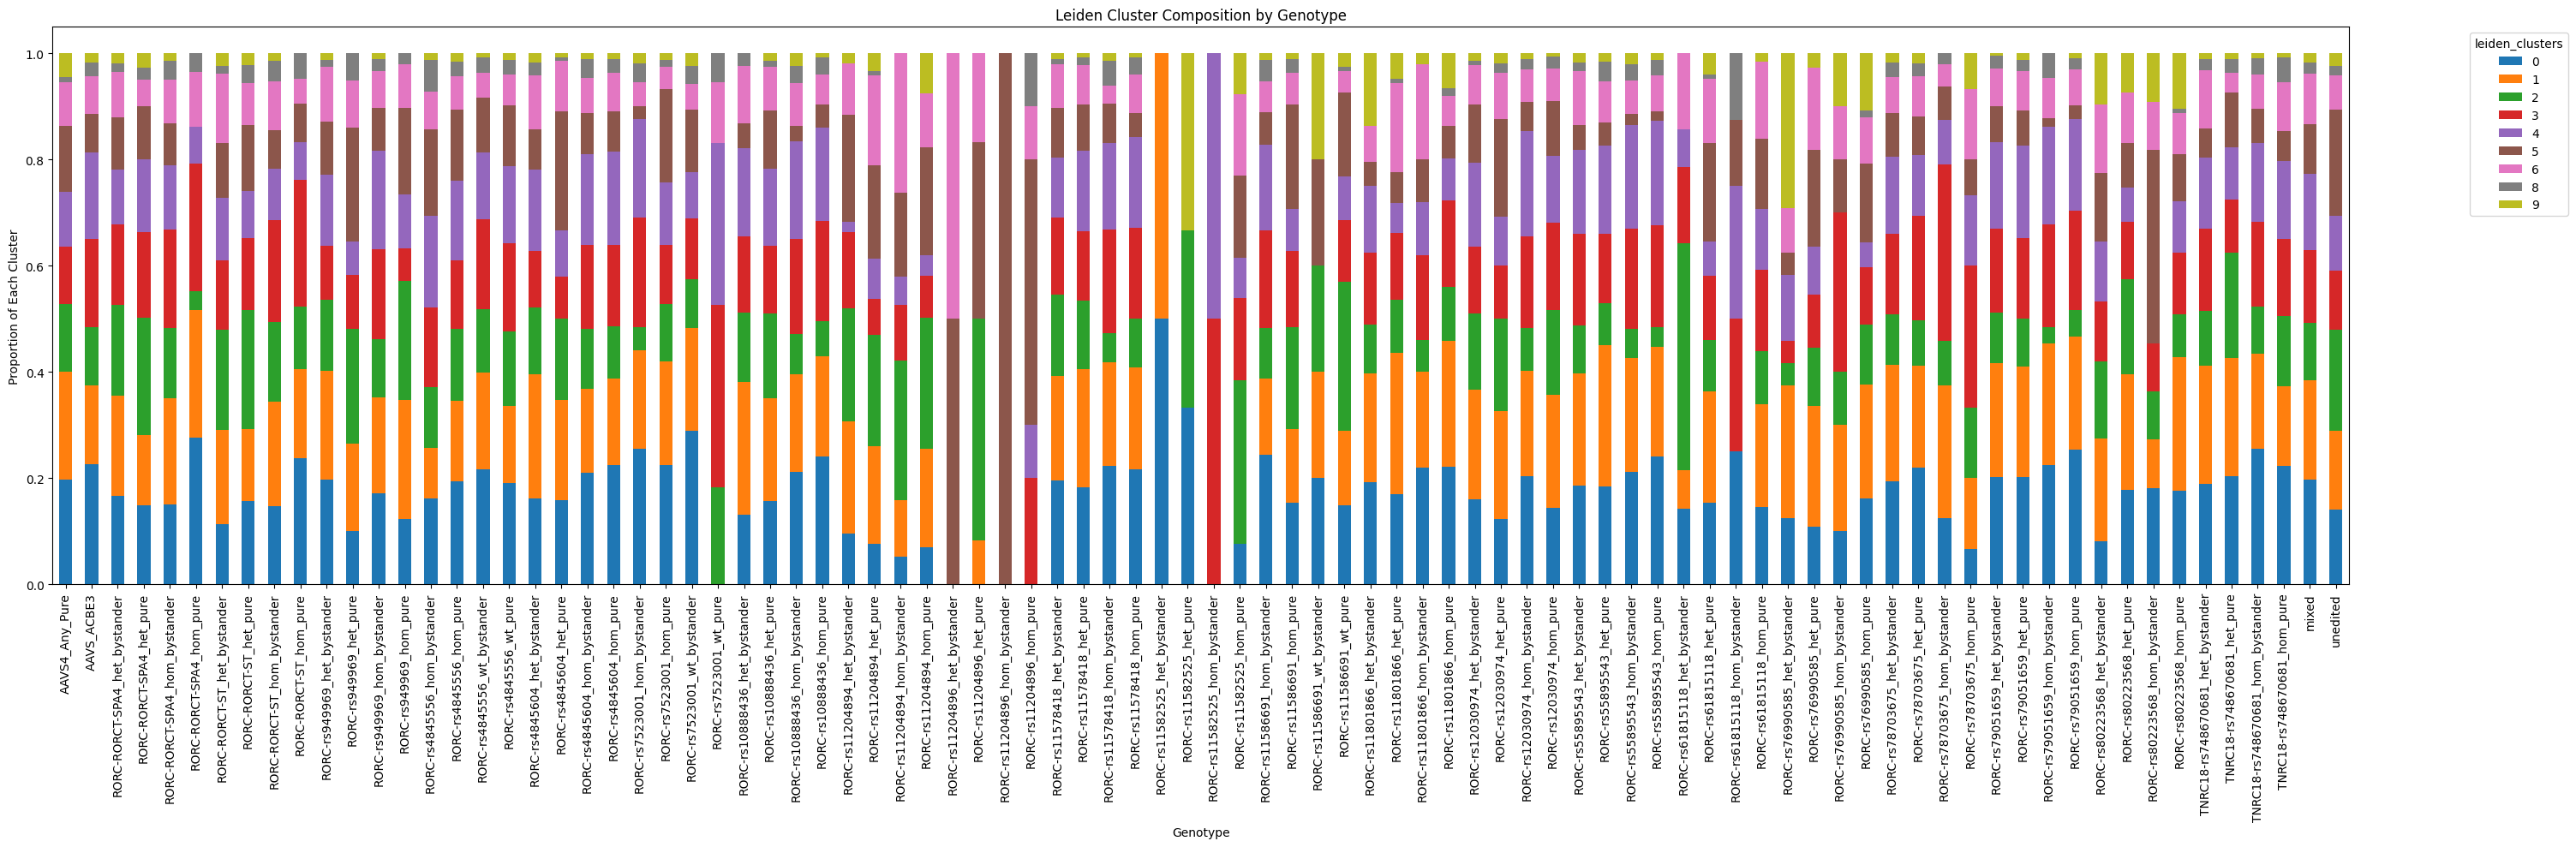

In [25]:
os.mkdir("../10_27_kai_figure/composition_change")
plot_genotype_cluster_composition(
    adata=adata_norm_filter,
    genotype_column='genotype_annotation',
    cluster_column='leiden_clusters',
    save_path="../10_27_kai_figure/composition_change",
    task_name="overall")

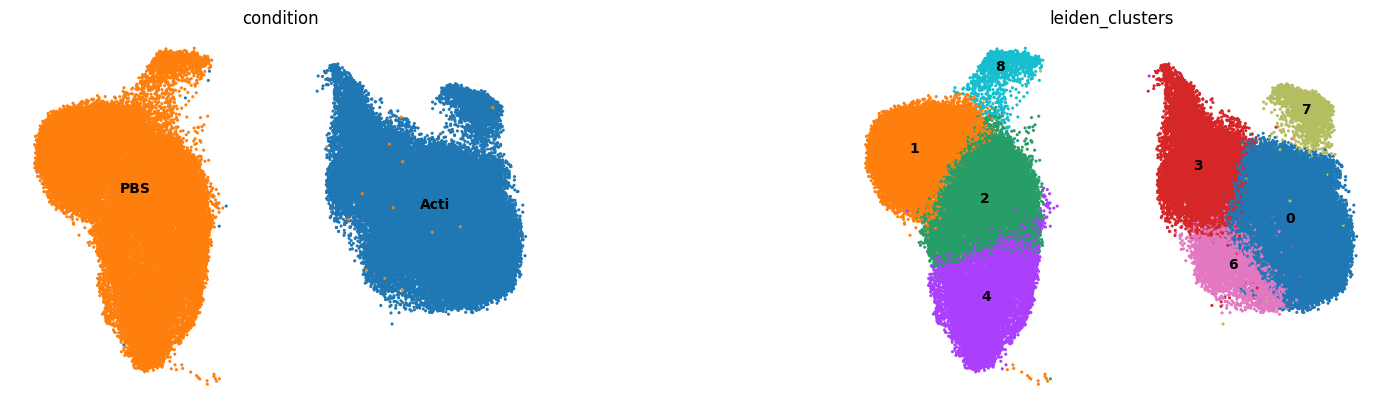

In [6]:
sc.pl.umap(adata_norm_filter, color=['condition', 'leiden_clusters'], wspace=0.4, ncols=2, size=20, frameon=False, legend_loc='on data')

In [38]:
naming_dict = {
    '0': 'pathogenic',
    '1': 'pathogenic',
    '2': 'pathogenic',
    '3': 'non-path',
    '4': 'non-path',
    '6': 'pathogenic',
    '7': 'non-path',
    '8': 'non-path' 
}

In [39]:
adata_norm_filter.obs["cluster_name"] = [naming_dict[i] for i in adata_norm_filter.obs["leiden_clusters"]]

/tmp/ipykernel_1989/1946671967.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  composition = df.groupby([genotype_column, cluster_column]).size().unstack(fill_value=0)


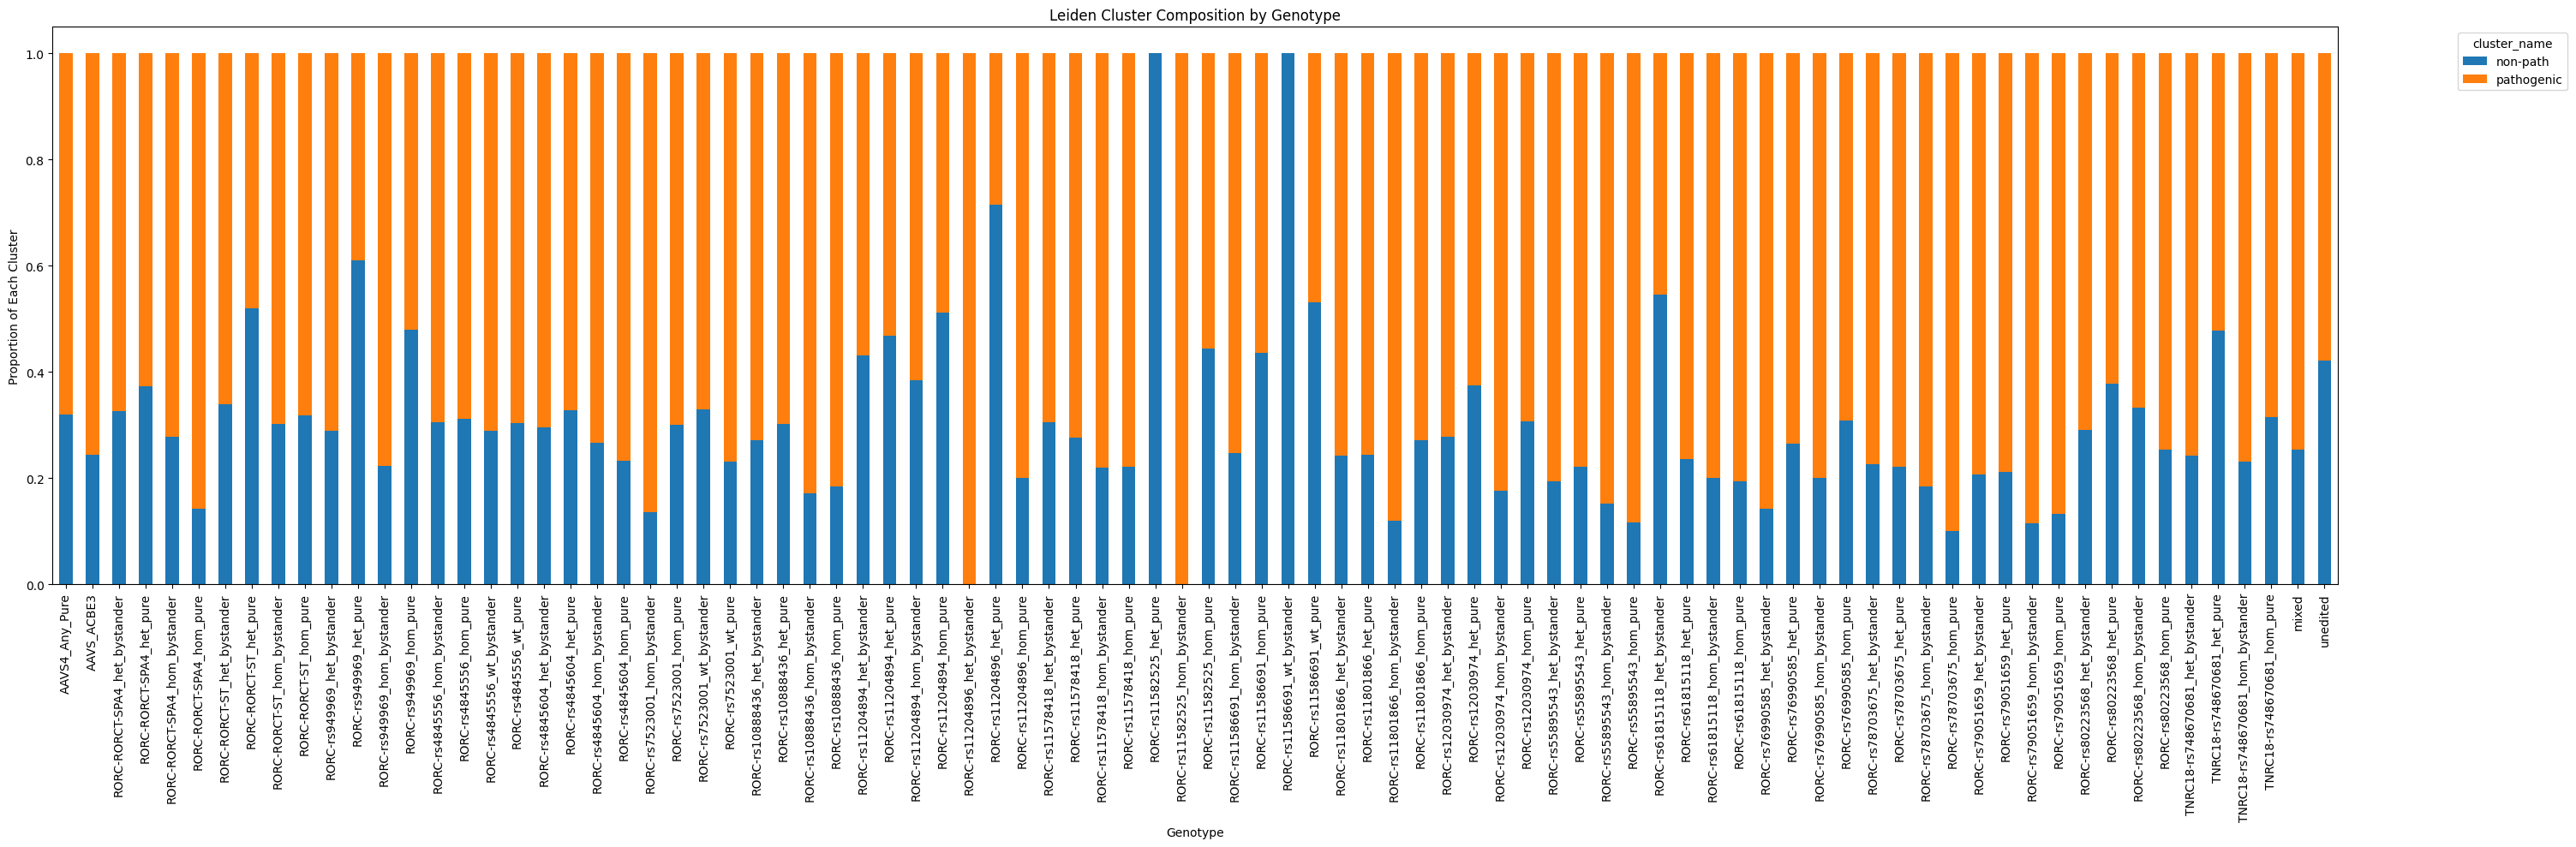

In [40]:
# subset the acti cells
adata_norm_filter_acti = adata_norm_filter[adata_norm_filter.obs["condition"] == "Acti"].copy()
# only keep 0, 3, 5, 7 for Acti cells
adata_norm_filter_acti = adata_norm_filter_acti[adata_norm_filter_acti.obs["leiden_clusters"].isin(['0','3','6', '7'])].copy()
plot_genotype_cluster_composition(
    adata=adata_norm_filter_acti,
    genotype_column='genotype_annotation',
    cluster_column='cluster_name',
    save_path="../10_16_kai_figure/composition_change",
    task_name="Acti")


In [41]:
df = adata_norm_filter_acti.obs[['genotype_annotation', 'cluster_name']]
composition = df.groupby(['genotype_annotation', 'cluster_name']).size().unstack(fill_value=0)
genotype_of_interst = [
    'AAVS4_Any_Pure', "RORC-rs11204894_het_pure", 
    "RORC-rs11204894_hom_pure", "RORC-rs11801866_het_pure",
    "RORC-rs11801866_hom_pure"
]

import pandas as pd
from scipy.stats import chi2_contingency, fisher_exact
from statsmodels.stats.multitest import multipletests
import warnings

df = composition[composition.index.isin(genotype_of_interst)]
# --- Step 2: Omnibus (Overall) Chi-square Test ---
# This test checks if there is a significant association across ALL 5 groups at once.
# It tells us if performing pairwise tests is statistically justified.
try:
    chi2, p, dof, expected = chi2_contingency(df)
    print("--- Omnibus Chi-square Test (All 5 Groups) ---")
    print(f"Chi-square statistic: {chi2:.4f}")
    print(f"P-value: {p:.4g}") # Use scientific notation for small p-values
    print("Interpretation:")
    if p < 0.05:
        print("The p-value is significant (p < 0.05). There is a significant difference in cell type proportions among the groups.")
        print("Proceeding with pairwise post-hoc tests is justified.\n")
    else:
        print("The p-value is not significant (p >= 0.05). There is no overall significant difference in cell type proportions.\n")
except ValueError as e:
    warnings.warn(f"Chi-square test failed, likely due to low counts. Error: {e}. Proceeding with pairwise tests.")


# --- Step 3: Pairwise Post-Hoc Tests ---
# We will compare each SNP genotype to the control group.
control_group = 'AAVS4_Any_Pure'
snp_groups = [
    'RORC-rs11204894_het_pure',
    'RORC-rs11204894_hom_pure',
    'RORC-rs11801866_het_pure',
    'RORC-rs11801866_hom_pure'
]

raw_p_values = []
test_used = []
print("--- Pairwise Post-Hoc Tests (vs. Control) ---")
for snp_group in snp_groups:
    # Create the 2xN contingency table for the pair
    sub_table = df.loc[[control_group, snp_group]]
    
    # IMPORTANT: Check for low expected counts. If any expected count is < 5,
    # Fisher's Exact Test is more appropriate than Chi-square.
    # The 'metabolic-active' column has a 0, which guarantees this condition.
    # For a 2x3 table, we simulate to get a p-value for Fisher's test.
    
    # We will use Fisher's Exact Test for all due to the presence of low counts (0 and 1)
    # which makes it the most robust choice here.
    try:
        # For tables larger than 2x2, fisher_exact can be computationally intensive.
        # It's suitable for this table size.
        _, p_pair = fisher_exact(sub_table)
        test_method = "Fisher's Exact Test"
    except Exception as e:
        # Fallback to Chi-square if Fisher's test fails for some reason
        warnings.warn(f"Fisher's test failed for {snp_group} ({e}), falling back to Chi-square.")
        _, p_pair, _, _ = chi2_contingency(sub_table)
        test_method = "Chi-square Test"

    raw_p_values.append(p_pair)
    test_used.append(test_method)
    
    print(f"Comparison: {control_group} vs. {snp_group}")
    print(f"  Test Used: {test_method}")
    print(f"  Raw P-value: {p_pair:.4g}\n")


# --- Step 4: P-value Correction for Multiple Comparisons ---
# Using Benjamini-Hochberg (FDR) to adjust for doing 4 separate tests.
reject, p_adjusted, _, _ = multipletests(raw_p_values, alpha=0.05, method='fdr_bh')


# --- Step 5: Final Results Summary ---
results_summary = pd.DataFrame({
    'Comparison': [f"{control_group} vs {snp}" for snp in snp_groups],
    'Test Used': test_used,
    'Raw P-value': raw_p_values,
    'Adjusted P-value (FDR)': p_adjusted,
    'Significant (alpha=0.05)': reject
})

print("--- Final Corrected Results Summary ---")
print(results_summary.to_string(index=False))
print("\n" + "="*50 + "\n")


# --- Step 6: Interpretation and Proportions ---
print("--- Interpretation of Results ---")
print("This detailed analysis allows for a more nuanced interpretation:")

# Calculate and display proportions
df_proportions = df.div(df.sum(axis=1), axis=0)
print("\n--- Cell Type Proportions by Group ---")
print((df_proportions * 100).round(2).to_string(float_format="%.2f%%"))

print("\n--- Summary of Findings ---")
# rs11204894
het_rs1_result = results_summary.iloc[0]
hom_rs1_result = results_summary.iloc[1]
print(f"\nVariant rs11204894:")
if het_rs1_result['Significant (alpha=0.05)']:
    print(f"  - The heterozygous state shows a SIGNIFICANT effect on cell proportions (p_adj = {het_rs1_result['Adjusted P-value (FDR)']:.2e}).")
else:
    print(f"  - The heterozygous state does NOT show a significant effect (p_adj = {het_rs1_result['Adjusted P-value (FDR)']:.2f}).")
if hom_rs1_result['Significant (alpha=0.05)']:
    print(f"  - The homozygous state shows a SIGNIFICANT effect on cell proportions (p_adj = {hom_rs1_result['Adjusted P-value (FDR)']:.2e}).")
else:
    print(f"  - The homozygous state does NOT show a significant effect (p_adj = {hom_rs1_result['Adjusted P-value (FDR)']:.2f}).")

# rs11801866
het_rs2_result = results_summary.iloc[2]
hom_rs2_result = results_summary.iloc[3]
print(f"\nVariant rs11801866:")
if het_rs2_result['Significant (alpha=0.05)']:
    print(f"  - The heterozygous state shows a SIGNIFICANT effect on cell proportions (p_adj = {het_rs2_result['Adjusted P-value (FDR)']:.2f}).")
else:
    print(f"  - The heterozygous state does NOT show a significant effect (p_adj = {het_rs2_result['Adjusted P-value (FDR)']:.2f}).")
if hom_rs2_result['Significant (alpha=0.05)']:
    print(f"  - The homozygous state shows a SIGNIFICANT effect on cell proportions (p_adj = {hom_rs2_result['Adjusted P-value (FDR)']:.2f}).")
else:
    print(f"  - The homozygous state does NOT show a significant effect (p_adj = {hom_rs2_result['Adjusted P-value (FDR)']:.2f}).")

--- Omnibus Chi-square Test (All 5 Groups) ---
Chi-square statistic: 37.1767
P-value: 1.656e-07
Interpretation:
The p-value is significant (p < 0.05). There is a significant difference in cell type proportions among the groups.
Proceeding with pairwise post-hoc tests is justified.

--- Pairwise Post-Hoc Tests (vs. Control) ---
Comparison: AAVS4_Any_Pure vs. RORC-rs11204894_het_pure
  Test Used: Fisher's Exact Test
  Raw P-value: 0.01837

Comparison: AAVS4_Any_Pure vs. RORC-rs11204894_hom_pure
  Test Used: Fisher's Exact Test
  Raw P-value: 6.91e-05

Comparison: AAVS4_Any_Pure vs. RORC-rs11801866_het_pure
  Test Used: Fisher's Exact Test
  Raw P-value: 0.02884

Comparison: AAVS4_Any_Pure vs. RORC-rs11801866_hom_pure
  Test Used: Fisher's Exact Test
  Raw P-value: 0.1138

--- Final Corrected Results Summary ---
                                Comparison           Test Used  Raw P-value  Adjusted P-value (FDR)  Significant (alpha=0.05)
AAVS4_Any_Pure vs RORC-rs11204894_het_pure Fisher's E

/tmp/ipykernel_1989/2470749794.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  composition = df.groupby(['genotype_annotation', 'cluster_name']).size().unstack(fill_value=0)


/tmp/ipykernel_1989/1946671967.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  composition = df.groupby([genotype_column, cluster_column]).size().unstack(fill_value=0)


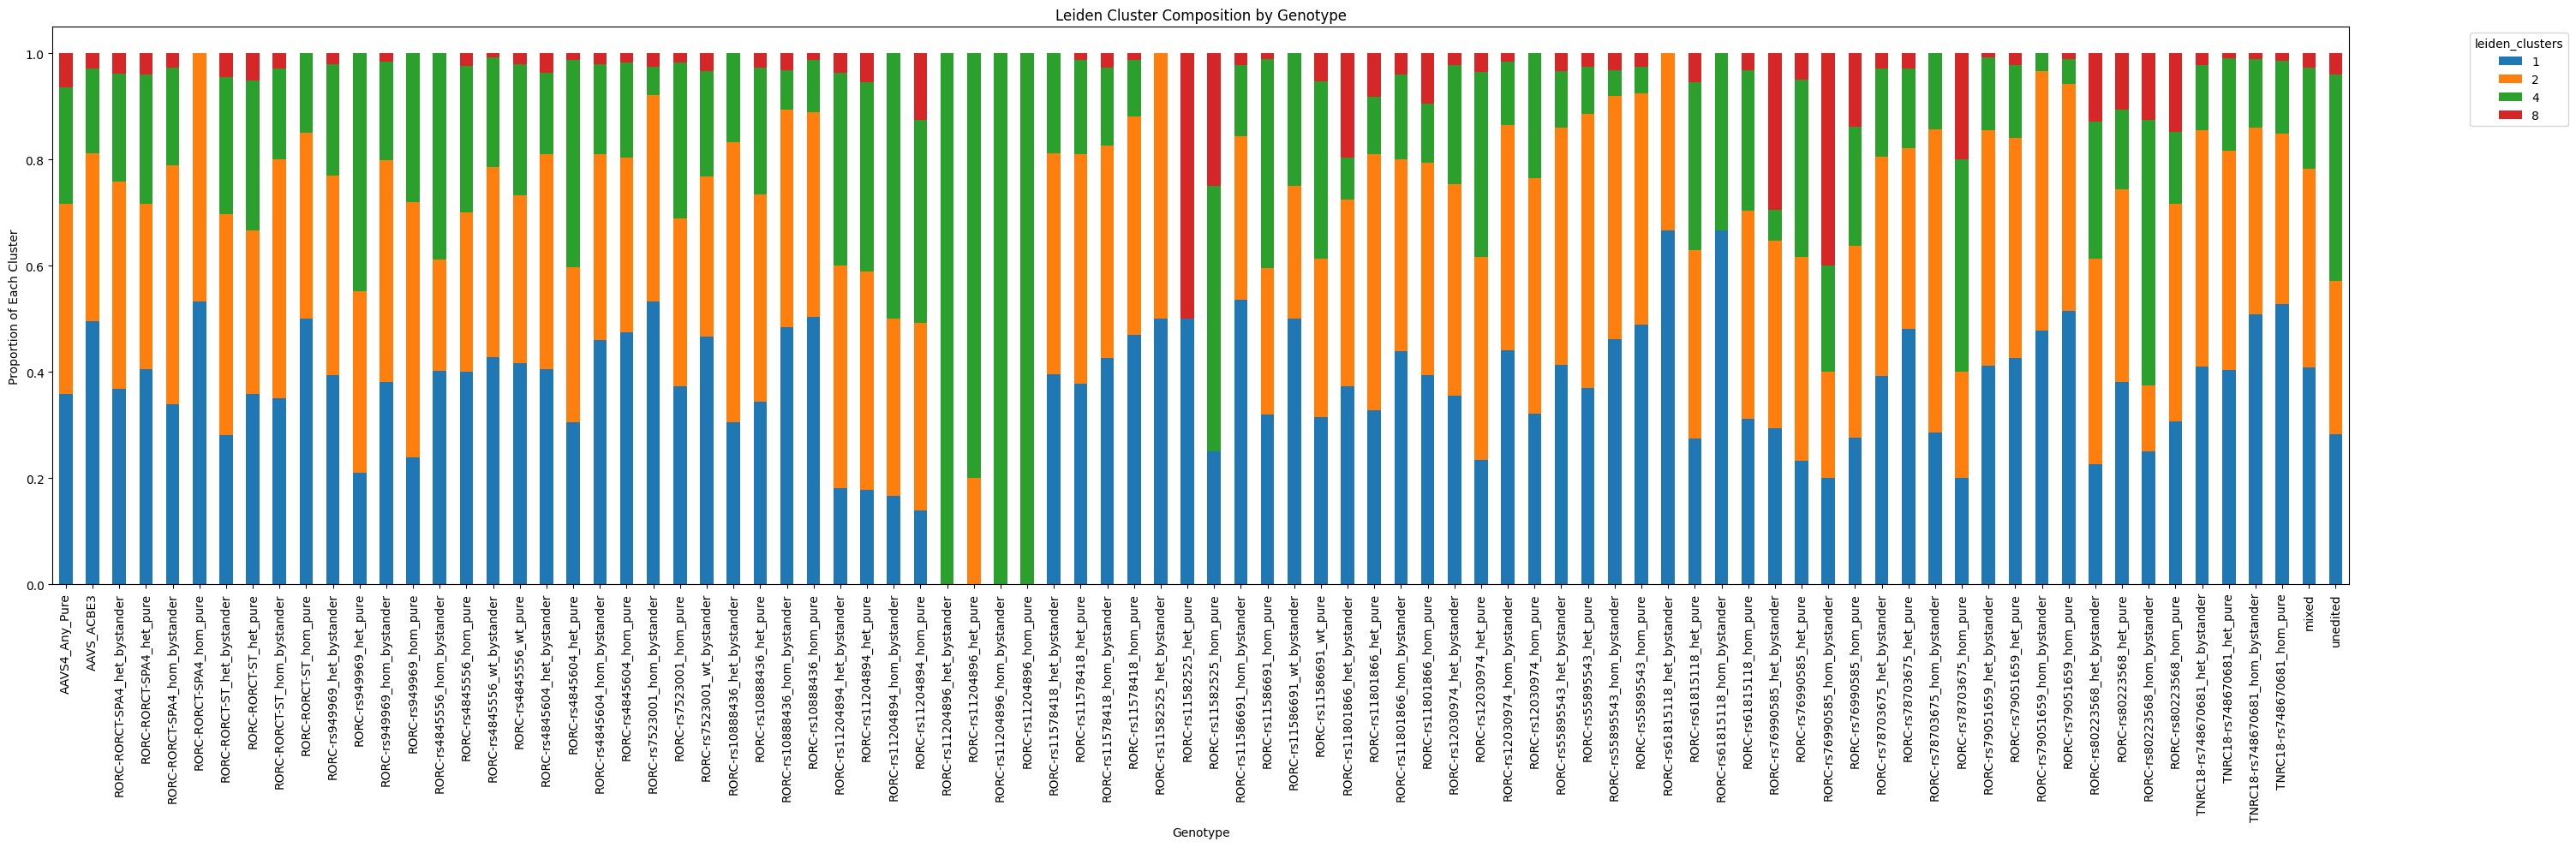

In [42]:
# plot PBS cells
# only keep 1, 2, 4, 8 for PBS cells
adata_norm_filter_pbs = adata_norm_filter[adata_norm_filter.obs["condition"] == "PBS"].copy()
adata_norm_filter_pbs = adata_norm_filter_pbs[adata_norm_filter_pbs.obs["leiden_clusters"].isin(['1','2','4','8'])].copy()

plot_genotype_cluster_composition(
    adata=adata_norm_filter_pbs,
    genotype_column='genotype_annotation',
    cluster_column='leiden_clusters',
    save_path="../10_16_kai_figure/composition_change",
    task_name="PBS")

In [43]:
df = adata_norm_filter_pbs.obs[['genotype_annotation', 'cluster_name']]
composition = df.groupby(['genotype_annotation', 'cluster_name']).size().unstack(fill_value=0)
genotype_of_interst = [
    'AAVS4_Any_Pure', "RORC-rs11204894_het_pure", 
    "RORC-rs11204894_hom_pure", "RORC-rs11801866_het_pure",
    "RORC-rs11801866_hom_pure"
]

import pandas as pd
from scipy.stats import chi2_contingency, fisher_exact
from statsmodels.stats.multitest import multipletests
import warnings

df = composition[composition.index.isin(genotype_of_interst)]
# --- Step 2: Omnibus (Overall) Chi-square Test ---
# This test checks if there is a significant association across ALL 5 groups at once.
# It tells us if performing pairwise tests is statistically justified.
try:
    chi2, p, dof, expected = chi2_contingency(df)
    print("--- Omnibus Chi-square Test (All 5 Groups) ---")
    print(f"Chi-square statistic: {chi2:.4f}")
    print(f"P-value: {p:.4g}") # Use scientific notation for small p-values
    print("Interpretation:")
    if p < 0.05:
        print("The p-value is significant (p < 0.05). There is a significant difference in cell type proportions among the groups.")
        print("Proceeding with pairwise post-hoc tests is justified.\n")
    else:
        print("The p-value is not significant (p >= 0.05). There is no overall significant difference in cell type proportions.\n")
except ValueError as e:
    warnings.warn(f"Chi-square test failed, likely due to low counts. Error: {e}. Proceeding with pairwise tests.")


# --- Step 3: Pairwise Post-Hoc Tests ---
# We will compare each SNP genotype to the control group.
control_group = 'AAVS4_Any_Pure'
snp_groups = [
    'RORC-rs11204894_het_pure',
    'RORC-rs11204894_hom_pure',
    'RORC-rs11801866_het_pure',
    'RORC-rs11801866_hom_pure'
]

raw_p_values = []
test_used = []
print("--- Pairwise Post-Hoc Tests (vs. Control) ---")
for snp_group in snp_groups:
    # Create the 2xN contingency table for the pair
    sub_table = df.loc[[control_group, snp_group]]
    
    # IMPORTANT: Check for low expected counts. If any expected count is < 5,
    # Fisher's Exact Test is more appropriate than Chi-square.
    # The 'metabolic-active' column has a 0, which guarantees this condition.
    # For a 2x3 table, we simulate to get a p-value for Fisher's test.
    
    # We will use Fisher's Exact Test for all due to the presence of low counts (0 and 1)
    # which makes it the most robust choice here.
    try:
        # For tables larger than 2x2, fisher_exact can be computationally intensive.
        # It's suitable for this table size.
        _, p_pair = fisher_exact(sub_table)
        test_method = "Fisher's Exact Test"
    except Exception as e:
        # Fallback to Chi-square if Fisher's test fails for some reason
        warnings.warn(f"Fisher's test failed for {snp_group} ({e}), falling back to Chi-square.")
        _, p_pair, _, _ = chi2_contingency(sub_table)
        test_method = "Chi-square Test"

    raw_p_values.append(p_pair)
    test_used.append(test_method)
    
    print(f"Comparison: {control_group} vs. {snp_group}")
    print(f"  Test Used: {test_method}")
    print(f"  Raw P-value: {p_pair:.4g}\n")


# --- Step 4: P-value Correction for Multiple Comparisons ---
# Using Benjamini-Hochberg (FDR) to adjust for doing 4 separate tests.
reject, p_adjusted, _, _ = multipletests(raw_p_values, alpha=0.05, method='fdr_bh')


# --- Step 5: Final Results Summary ---
results_summary = pd.DataFrame({
    'Comparison': [f"{control_group} vs {snp}" for snp in snp_groups],
    'Test Used': test_used,
    'Raw P-value': raw_p_values,
    'Adjusted P-value (FDR)': p_adjusted,
    'Significant (alpha=0.05)': reject
})

print("--- Final Corrected Results Summary ---")
print(results_summary.to_string(index=False))
print("\n" + "="*50 + "\n")


# --- Step 6: Interpretation and Proportions ---
print("--- Interpretation of Results ---")
print("This detailed analysis allows for a more nuanced interpretation:")

# Calculate and display proportions
df_proportions = df.div(df.sum(axis=1), axis=0)
print("\n--- Cell Type Proportions by Group ---")
print((df_proportions * 100).round(2).to_string(float_format="%.2f%%"))

print("\n--- Summary of Findings ---")
# rs11204894
het_rs1_result = results_summary.iloc[0]
hom_rs1_result = results_summary.iloc[1]
print(f"\nVariant rs11204894:")
if het_rs1_result['Significant (alpha=0.05)']:
    print(f"  - The heterozygous state shows a SIGNIFICANT effect on cell proportions (p_adj = {het_rs1_result['Adjusted P-value (FDR)']:.2e}).")
else:
    print(f"  - The heterozygous state does NOT show a significant effect (p_adj = {het_rs1_result['Adjusted P-value (FDR)']:.2f}).")
if hom_rs1_result['Significant (alpha=0.05)']:
    print(f"  - The homozygous state shows a SIGNIFICANT effect on cell proportions (p_adj = {hom_rs1_result['Adjusted P-value (FDR)']:.2e}).")
else:
    print(f"  - The homozygous state does NOT show a significant effect (p_adj = {hom_rs1_result['Adjusted P-value (FDR)']:.2f}).")

# rs11801866
het_rs2_result = results_summary.iloc[2]
hom_rs2_result = results_summary.iloc[3]
print(f"\nVariant rs11801866:")
if het_rs2_result['Significant (alpha=0.05)']:
    print(f"  - The heterozygous state shows a SIGNIFICANT effect on cell proportions (p_adj = {het_rs2_result['Adjusted P-value (FDR)']:.2f}).")
else:
    print(f"  - The heterozygous state does NOT show a significant effect (p_adj = {het_rs2_result['Adjusted P-value (FDR)']:.2f}).")
if hom_rs2_result['Significant (alpha=0.05)']:
    print(f"  - The homozygous state shows a SIGNIFICANT effect on cell proportions (p_adj = {hom_rs2_result['Adjusted P-value (FDR)']:.2f}).")
else:
    print(f"  - The homozygous state does NOT show a significant effect (p_adj = {hom_rs2_result['Adjusted P-value (FDR)']:.2f}).")

--- Omnibus Chi-square Test (All 5 Groups) ---
Chi-square statistic: 66.3896
P-value: 1.311e-13
Interpretation:
The p-value is significant (p < 0.05). There is a significant difference in cell type proportions among the groups.
Proceeding with pairwise post-hoc tests is justified.

--- Pairwise Post-Hoc Tests (vs. Control) ---
Comparison: AAVS4_Any_Pure vs. RORC-rs11204894_het_pure
  Test Used: Fisher's Exact Test
  Raw P-value: 0.04881

Comparison: AAVS4_Any_Pure vs. RORC-rs11204894_hom_pure
  Test Used: Fisher's Exact Test
  Raw P-value: 3.374e-07

Comparison: AAVS4_Any_Pure vs. RORC-rs11801866_het_pure
  Test Used: Fisher's Exact Test
  Raw P-value: 0.001612

Comparison: AAVS4_Any_Pure vs. RORC-rs11801866_hom_pure
  Test Used: Fisher's Exact Test
  Raw P-value: 0.0008891

--- Final Corrected Results Summary ---
                                Comparison           Test Used  Raw P-value  Adjusted P-value (FDR)  Significant (alpha=0.05)
AAVS4_Any_Pure vs RORC-rs11204894_het_pure Fishe

/tmp/ipykernel_1989/2294354390.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  composition = df.groupby(['genotype_annotation', 'cluster_name']).size().unstack(fill_value=0)


In [30]:
# Extra Task Oct. 15: box plot for AAVS_ACBE3 vs RORCT_SPA4_hom_bystander and AAVS_ACBE3 vs RORCT_ST_hom_bystander, for 
# 5 genes, RORC, RORC201, RORC202, IL17A, IL17F

def plot_treatment_comparison_grid(adata, genes, condition_col, genotype_col, output_path):
    """
    Generates a 2x5 grid of boxplots with Mann-Whitney U p-value annotations.

    The grid compares expression of 5 genes across 2 conditions (PBS vs. Acti).
    Each subplot is a boxplot comparing three genotypes: AAVS_ACBE3 (control),
    RORCT_SPA4_hom_bystander, and RORCT_ST_hom_bystander.

    Args:
        adata (sc.AnnData): The annotated AnnData object.
        genes (list): A list of exactly 5 gene names for the columns.
        condition_col (str): The column name in adata.obs for conditions.
        genotype_col (str): The column name in adata.obs with genotype annotations.
        output_path (str): The path to save the final PNG figure.
    """
    if len(genes) != 5:
        print("Error: Please provide a list of exactly 5 genes.")
        return

    # --- 1. Setup Figure and Define Groups ---
    fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(35, 15), sharey=True)
    sns.set_style("ticks")

    conditions = ['PBS', 'Acti']
    genotypes_to_compare = ['AAVS_ACBE3', 'RORC-RORCT-SPA4_hom_bystander', 'RORC-RORCT-ST_hom_bystander']
    control_geno = 'AAVS_ACBE3'
    comparisons = {
        'SPA4': 'RORC-RORCT-SPA4_hom_bystander',
        'ST': 'RORC-RORCT-ST_hom_bystander'
    }
    # --- 2. Nested Loop to Create Subplots ---
    # --- Loop through each comparison to create a separate figure ---
    for comp_name, target_geno in comparisons.items():
        
        # --- 1. Setup Figure ---
        fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(10, 10), sharey=True)
        sns.set_style("ticks")
        genotypes_to_plot = [control_geno, target_geno]

        # --- 2. Nested Loop to Create Subplots ---
        for row_idx, condition in enumerate(conditions):
            for col_idx, gene in enumerate(genes):
                ax = axes[row_idx, col_idx]

                # --- 3. Filter Data for the Subplot ---
                adata_cond = adata[adata.obs[condition_col] == condition]
                adata_plot = adata_cond[adata_cond.obs[genotype_col].isin(genotypes_to_plot)]

                if adata_plot.n_obs < 2: # Need at least two groups to compare
                    ax.text(0.5, 0.5, 'No/insufficient data', ha='center', va='center')
                    ax.set_title(f"{gene}\n({condition})")
                    continue
                
                df_plot = pd.DataFrame({
                    'Expression': adata_plot[:, gene].X.toarray().flatten(),
                    'Genotype': adata_plot.obs[genotype_col]
                })

                # --- 4. Create Boxplot and Stripplot ---
                sns.boxplot(data=df_plot, x='Genotype', y='Expression', ax=ax,
                            order=genotypes_to_plot, palette="muted", fliersize=0)
                sns.stripplot(data=df_plot, x='Genotype', y='Expression', ax=ax,
                              order=genotypes_to_plot, palette="muted", size=3,
                              jitter=True, alpha=0.6)
                
                # --- 5. Perform Stat Test and Annotate ---
                data_control = df_plot[df_plot['Genotype'] == control_geno]['Expression'].dropna()
                data_target = df_plot[df_plot['Genotype'] == target_geno]['Expression'].dropna()
                y_max = df_plot['Expression'].max()

                if len(data_control) > 0 and len(data_target) > 0:
                    stat, p_val = mannwhitneyu(data_control, data_target, alternative='two-sided')
                    
                    # Conditional p-value formatting
                    if p_val < 0.001:
                        p_text = f"p = {p_val:.2e}"
                    else:
                        p_text = f"p = {p_val:.3f}"

                    ax.plot([0, 0, 1, 1], [y_max*1.02, y_max*1.07, y_max*1.07, y_max*1.02], lw=1.5, c='black')
                    ax.text(0.5, y_max*1.09, p_text, ha='center', va='bottom')

                # --- 6. Finalize Subplot Aesthetics ---
                ax.set_title(f"{gene}\n({condition})", fontsize=12)
                ax.set_xlabel('')
                ax.set_ylabel('Norm. Expression' if col_idx == 0 else '')
                ax.tick_params(axis='x', rotation=45)

        # --- 7. Finalize and Save Full Figure ---
        plt.tight_layout(pad=1.5)
        fig.suptitle(f"Gene Expression Comparison: Control vs. {comp_name}", fontsize=16, y=1.02)
        
        output_path = f"{output_path}_{comp_name}_vs_Control.pdf"
        print(f"Saving figure to {output_path}")
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.close()

/tmp/ipykernel_5475/3495156210.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Genotype', y='Expression', ax=ax,
/tmp/ipykernel_5475/3495156210.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df_plot, x='Genotype', y='Expression', ax=ax,
/tmp/ipykernel_5475/3495156210.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Genotype', y='Expression', ax=ax,
/tmp/ipykernel_5475/3495156210.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.

Saving figure to /mnt/data/project/25_09_15_rorc_th17_new/10_27_kai_figure/1027_boxplot/test_SPA4_vs_Control.pdf


/tmp/ipykernel_5475/3495156210.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Genotype', y='Expression', ax=ax,
/tmp/ipykernel_5475/3495156210.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df_plot, x='Genotype', y='Expression', ax=ax,
/tmp/ipykernel_5475/3495156210.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Genotype', y='Expression', ax=ax,
/tmp/ipykernel_5475/3495156210.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.

Saving figure to /mnt/data/project/25_09_15_rorc_th17_new/10_27_kai_figure/1027_boxplot/test_SPA4_vs_Control.pdf_ST_vs_Control.pdf


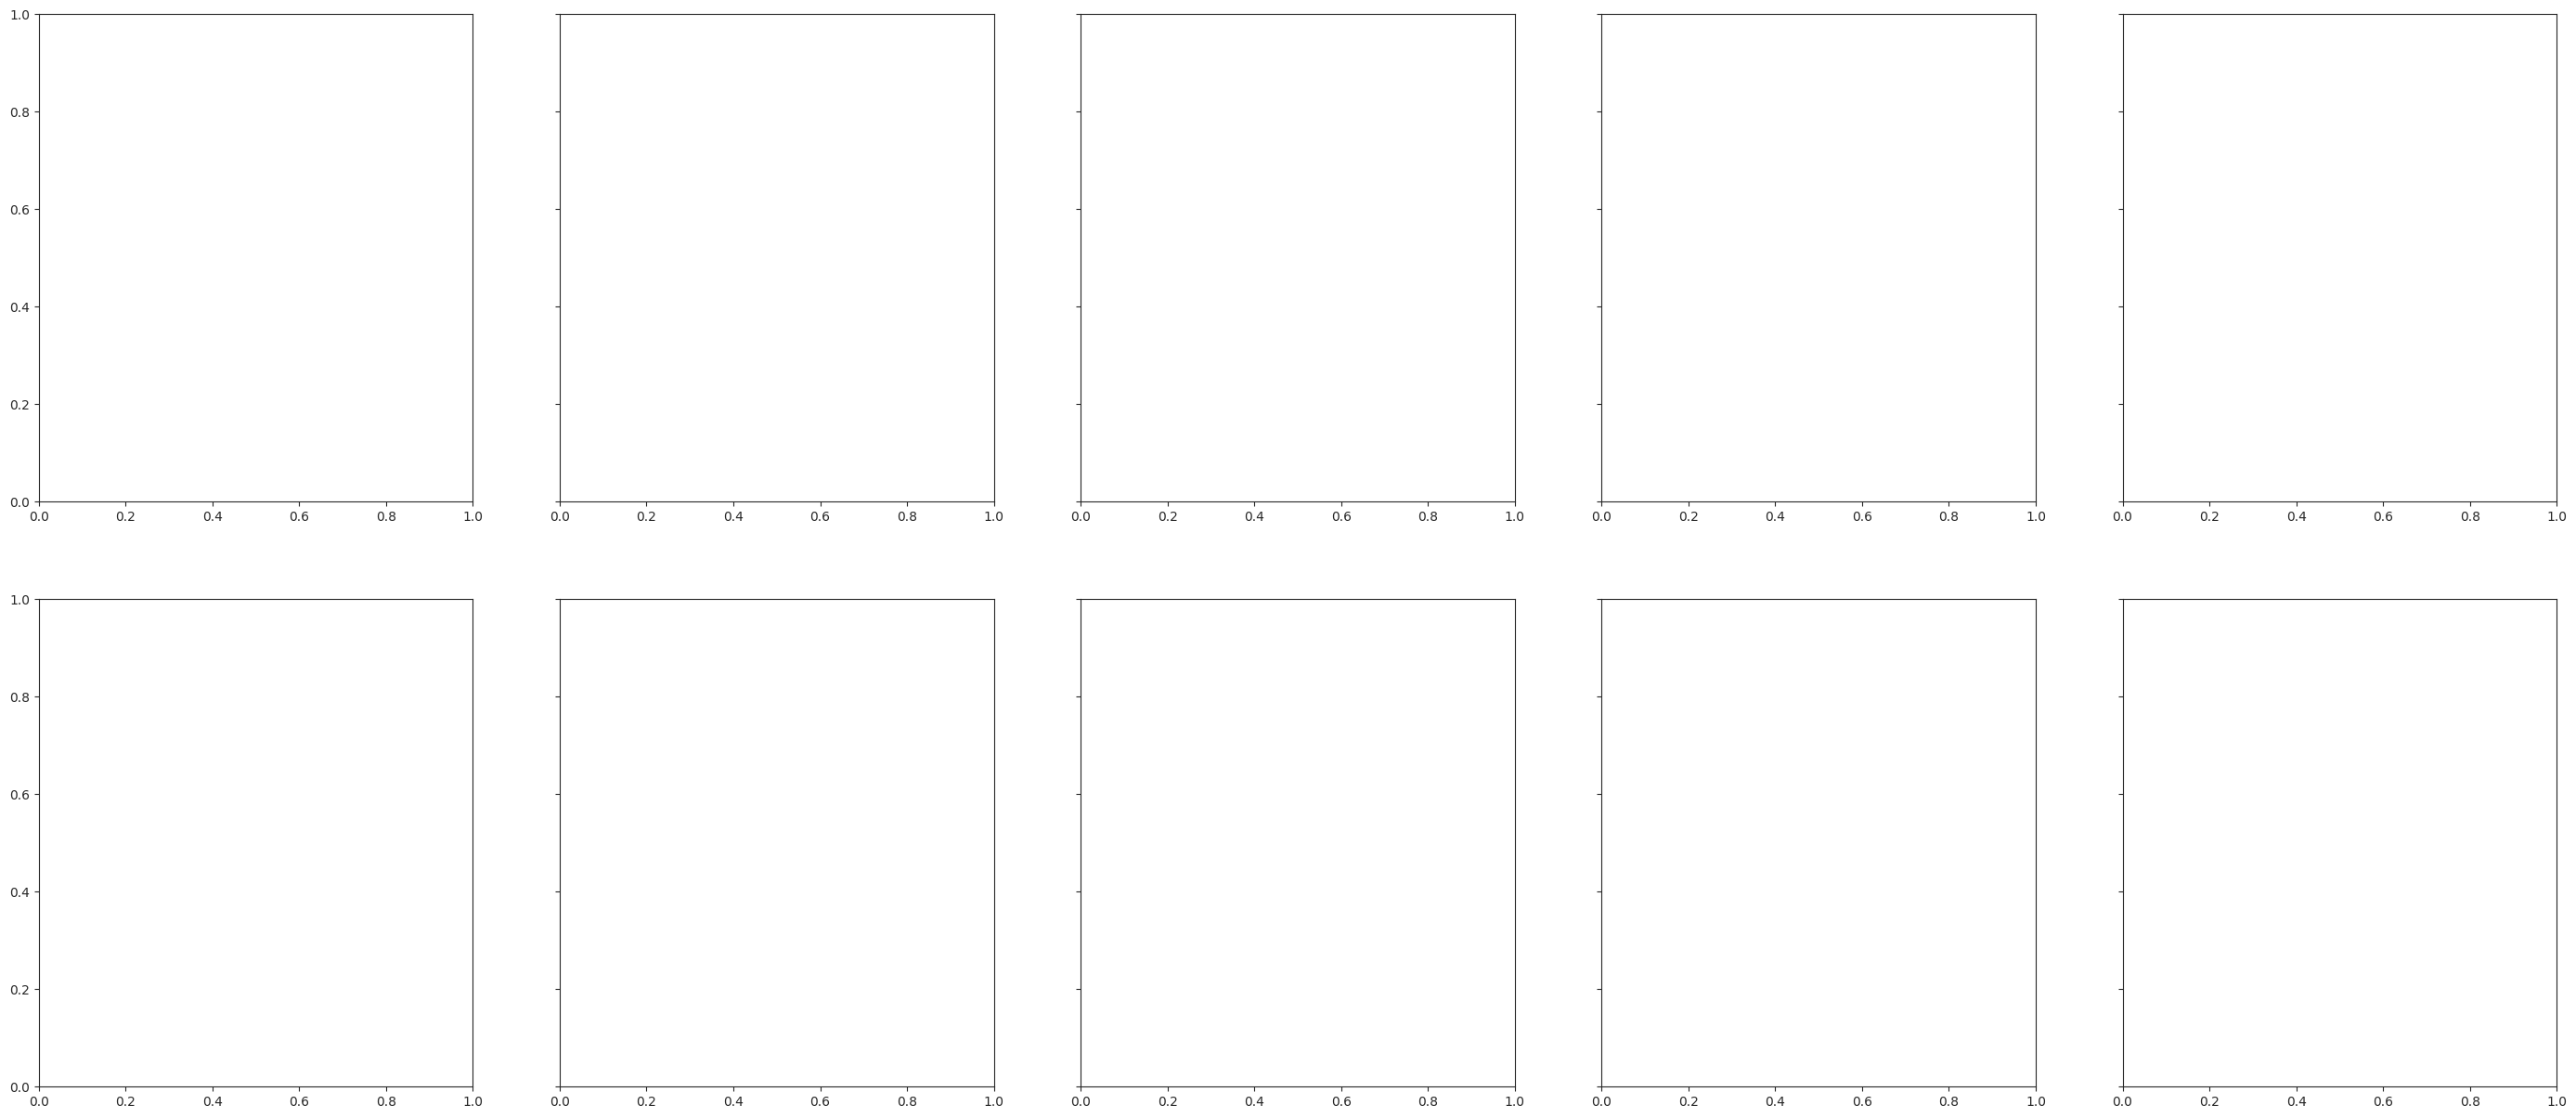

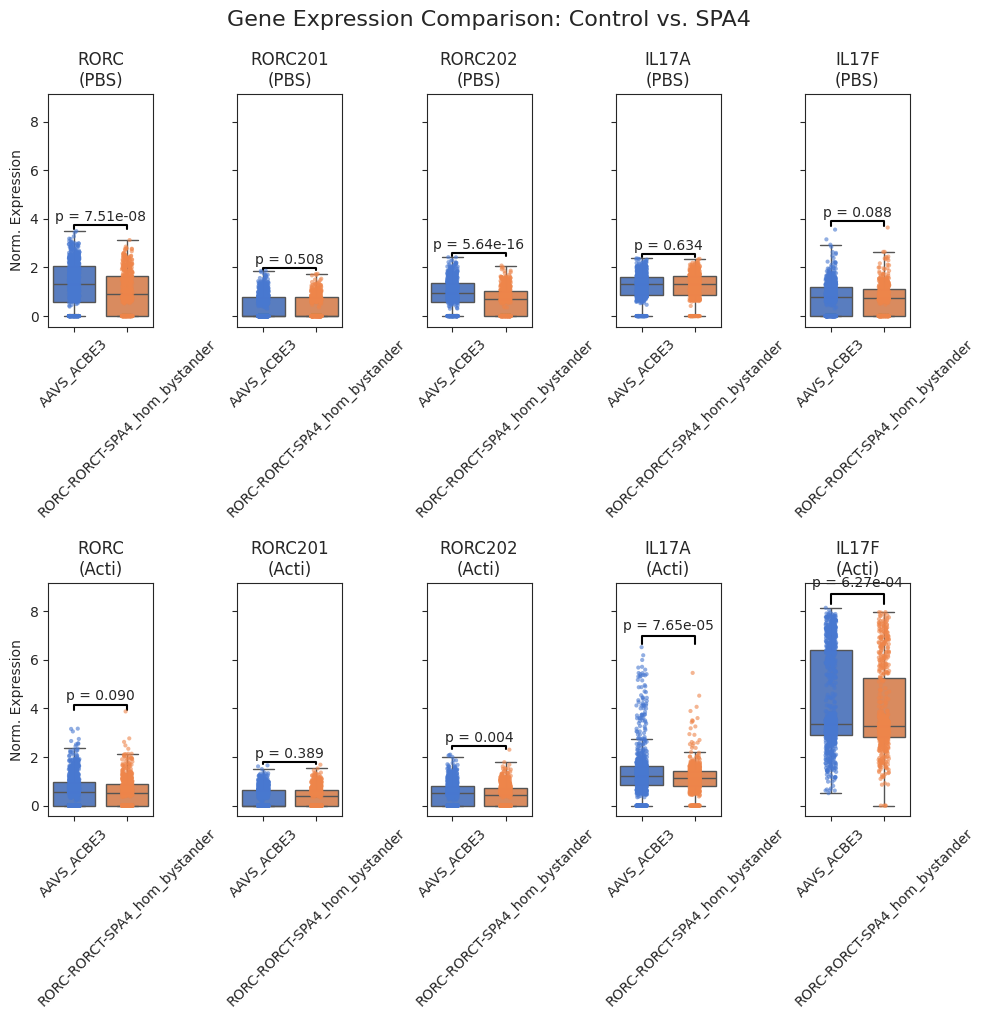

In [ ]:
GENES_FOR_GRID = ['RORC', 'RORC201', 'RORC202', 'IL17A', 'IL17F']
OUTPUT_FILE_GRID = "../Data/figure6/10_27_kai_figure/1027_boxplot/test"
os.mkdir("../Data/figure6/10_27_kai_figure/1027_boxplot", exist_ok=True)
plot_treatment_comparison_grid(
        adata=adata_norm_filter,
        genes=GENES_FOR_GRID,
        condition_col='condition',
        genotype_col='genotype_annotation',
        output_path=OUTPUT_FILE_GRID
    )